# Result Analysis

This notebook contains the analysis and visualization of voting prediction results.
Separated from the experiment running for better organization.

In [2]:
# Core imports
import os
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jupyterlab.labapp import clean_aliases

from openai import OpenAI
from importlib import reload

# Local imports
import SoD_Utils
import Save_Utils
import Visualization_Utils
import VotingResult
import Models_Utils
import Data

In [4]:
# Configuration
LANGUAGE = SoD_Utils.LANGUAGE_CZ
temperature = 0

# Load original data for claimed results comparison
data_path = SoD_Utils.get_dataset_path(LANGUAGE)
df = pd.read_spss(data_path)

# Vectorized extraction without Python loop
data = df[['Q21']].rename(columns={'Q21': 'voted_party'})

actual_parties, actual_attendance = Data.ELECTION_DATA

print(f"Loaded survey data: {len(data)} respondents")

Loaded survey data: 3880 respondents


In [5]:
# Load voting results from saved files
# Modify the model name and file path as needed
model = "gpt-4o"

# Load results
voting_results = Save_Utils.load_results_from_json(
    f"results/voting_results_n=3880_t={temperature}_{model}.json", 
    VotingResult.VotingResult
)

print(f"Loaded voting results: {len(voting_results)} respondents")
print(f"Model: {model}")
print(f"Temperature: {temperature}")

Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o.json
Loaded voting results: 3880 respondents
Model: gpt-4o
Temperature: 0


## Result Evaluation

Validate the quality of the voting results by checking for common issues.

In [4]:
# Evaluate voting results quality
tol = 0.01
bad_voted_sum, bad_party_probs_sum, duplicate_parties = VotingResult.evaluate_voting_results(voting_results, tol)

# Print details
if bad_voted_sum:
    print(f"[WARN] {len(bad_voted_sum)} respondents where voted+not_voted != 1 (|delta|>{tol}):")
    for rid, v, nv, s in bad_voted_sum[:20]:
        print(f" - ID={rid}: voted={v:.3f}, not_voted={nv:.3f}, sum={s:.3f}")
    if len(bad_voted_sum) > 20:
        print(f" ... and {len(bad_voted_sum)-20} more")
else:
    print("[OK] All respondents have voted+not_voted summing to 1 within tolerance.")

if bad_party_probs_sum:
    print(f"[WARN] {len(bad_party_probs_sum)} respondents where party probabilities don't sum to 1 (|delta|>{tol}):")
    for rid, s, v in bad_party_probs_sum[:20]:
        print(f" - ID={rid}: voted={v}, prob_sum={s:.3f}")
    if len(bad_party_probs_sum) > 20:
        print(f" ... and {len(bad_party_probs_sum)-20} more")
else:
    print("[OK] All respondents have party probabilities summing to 1 within tolerance (when parties present).")

if duplicate_parties:
    print(f"[WARN] {len(duplicate_parties)} respondents with duplicate party names:")
    for rid, dups in duplicate_parties[:20]:
        print(f" - ID={rid}: duplicates={dups}")
    if len(duplicate_parties) > 20:
        print(f" ... and {len(duplicate_parties)-20} more")
else:
    print("[OK] No duplicate party names found in any respondent's parties list.")

[OK] All respondents have voted+not_voted summing to 1 within tolerance.
[WARN] 174 respondents where party probabilities don't sum to 1 (|delta|>0.01):
 - ID=58: voted=0.3, prob_sum=1.050
 - ID=125: voted=0.7, prob_sum=1.100
 - ID=149: voted=0.6, prob_sum=1.100
 - ID=211: voted=0.3, prob_sum=1.050
 - ID=223: voted=0.7, prob_sum=1.100
 - ID=259: voted=0.6, prob_sum=1.100
 - ID=283: voted=0.9, prob_sum=1.020
 - ID=356: voted=0.8, prob_sum=1.050
 - ID=360: voted=0.8, prob_sum=1.100
 - ID=348: voted=0.6, prob_sum=1.100
 - ID=414: voted=0.6, prob_sum=1.100
 - ID=473: voted=0.7, prob_sum=1.100
 - ID=479: voted=0.6, prob_sum=1.100
 - ID=493: voted=0.9, prob_sum=1.020
 - ID=489: voted=0.7, prob_sum=1.100
 - ID=499: voted=0.9, prob_sum=1.100
 - ID=513: voted=0.7, prob_sum=1.100
 - ID=527: voted=0.7, prob_sum=1.100
 - ID=536: voted=0.6, prob_sum=1.100
 - ID=551: voted=0.9, prob_sum=1.010
 ... and 154 more
[WARN] 6 respondents with duplicate party names:
 - ID=694: duplicates=['ANO 2011', 'Koali

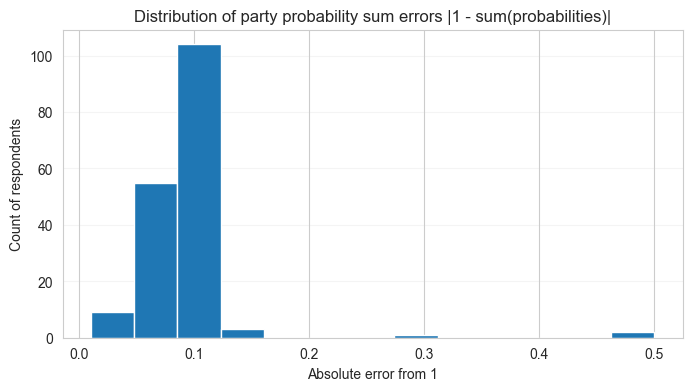

In [5]:
# Visualize party probability errors
if bad_party_probs_sum:
    Visualization_Utils.visualize_party_errors([abs(1-s) for _, s, _ in bad_party_probs_sum])
else:
    print("No party probability errors to visualize.")

## Visualization

Generate comprehensive visualizations comparing predicted vs actual results.

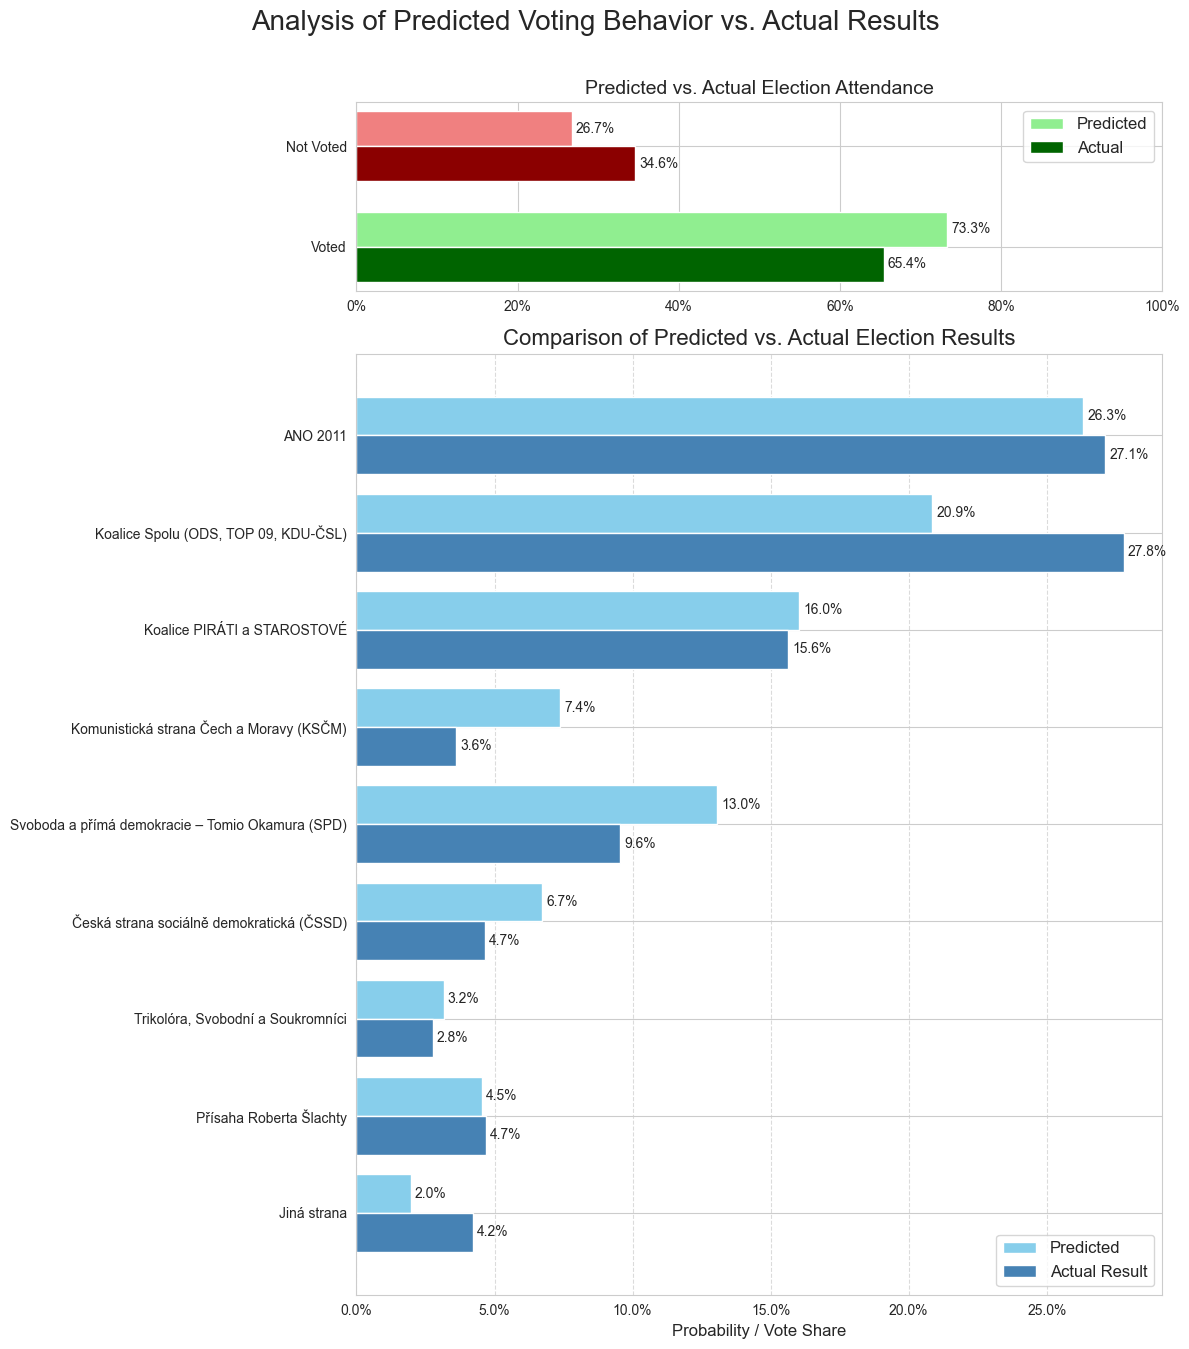

In [6]:
# Generate aggregated results and visualizations
predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(list(voting_results.values()), True)

# Visualize the results
fig = Visualization_Utils.visualize_comprehensive_results(
    predicted_parties,
    predicted_attendance,
    actual_parties,
    actual_attendance
)

## Comparative Analysis

Compare multiple models and generate error analysis.

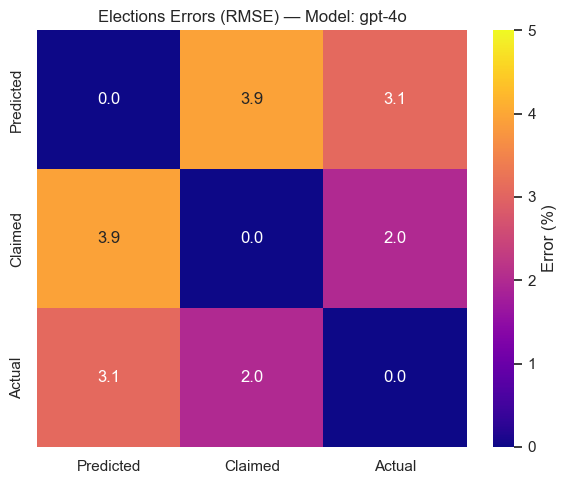

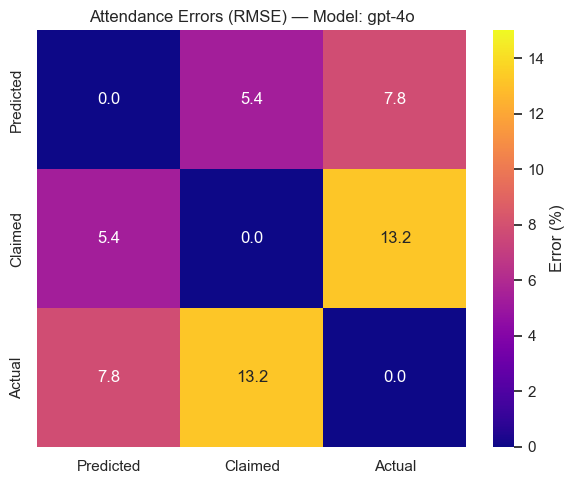

In [7]:
# Compare current model with claimed and actual results
metric = 'RMSE'  # or 'MAE'

# Get claimed results from survey data
claimed_parties, claimed_attendance = SoD_Utils.get_actual_results(
    data.iloc[list(voting_results.keys())]
)

# Generate comparison plots
Visualization_Utils.evaluate_polls(predicted_parties, claimed_parties, actual_parties, metric, "Elections", model)
Visualization_Utils.evaluate_polls(predicted_attendance, claimed_attendance, actual_attendance, metric, "Attendance", model, 15)

## Multi-Model Comparison

Compare results across different models.

In [11]:
# List of model names to compare
model_names = [
    "gpt-4.1-nano",
    "gpt-4o-mini",
    "gpt-4.1",
    "gpt-4o"
]

# Load all model results
voting_results_list = []
for model_name in model_names:
    try:
        file_suffix = "_(uncertain_ID)" if model_name != "gpt-4o" else ""
        results = Save_Utils.load_results_from_json(
            f"results/voting_results_n=3880_t=0_{model_name}{"_(uncertain_ID)" if model_name!="gpt-4o" else ""}.json",
            VotingResult.VotingResult
        )
        voting_results_list.append(results)
        print(f"✓ Loaded {model_name}: {len(results)} respondents")
    except FileNotFoundError:
        print(f"✗ File not found for {model_name}")
        voting_results_list.append({})

print(f"\nSuccessfully loaded {len([r for r in voting_results_list if r])} model results.")

Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4.1-nano_(uncertain_ID).json
✓ Loaded gpt-4.1-nano: 3880 respondents
Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o-mini_(uncertain_ID).json
✓ Loaded gpt-4o-mini: 3880 respondents
Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4.1_(uncertain_ID).json
✓ Loaded gpt-4.1: 3880 respondents
Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o.json
✓ Loaded gpt-4o: 3880 respondents

Successfully loaded 4 model results.


Saved graph for gpt-4.1-nano
Saved graph for gpt-4o-mini
Saved graph for gpt-4.1
Saved graph for gpt-4o


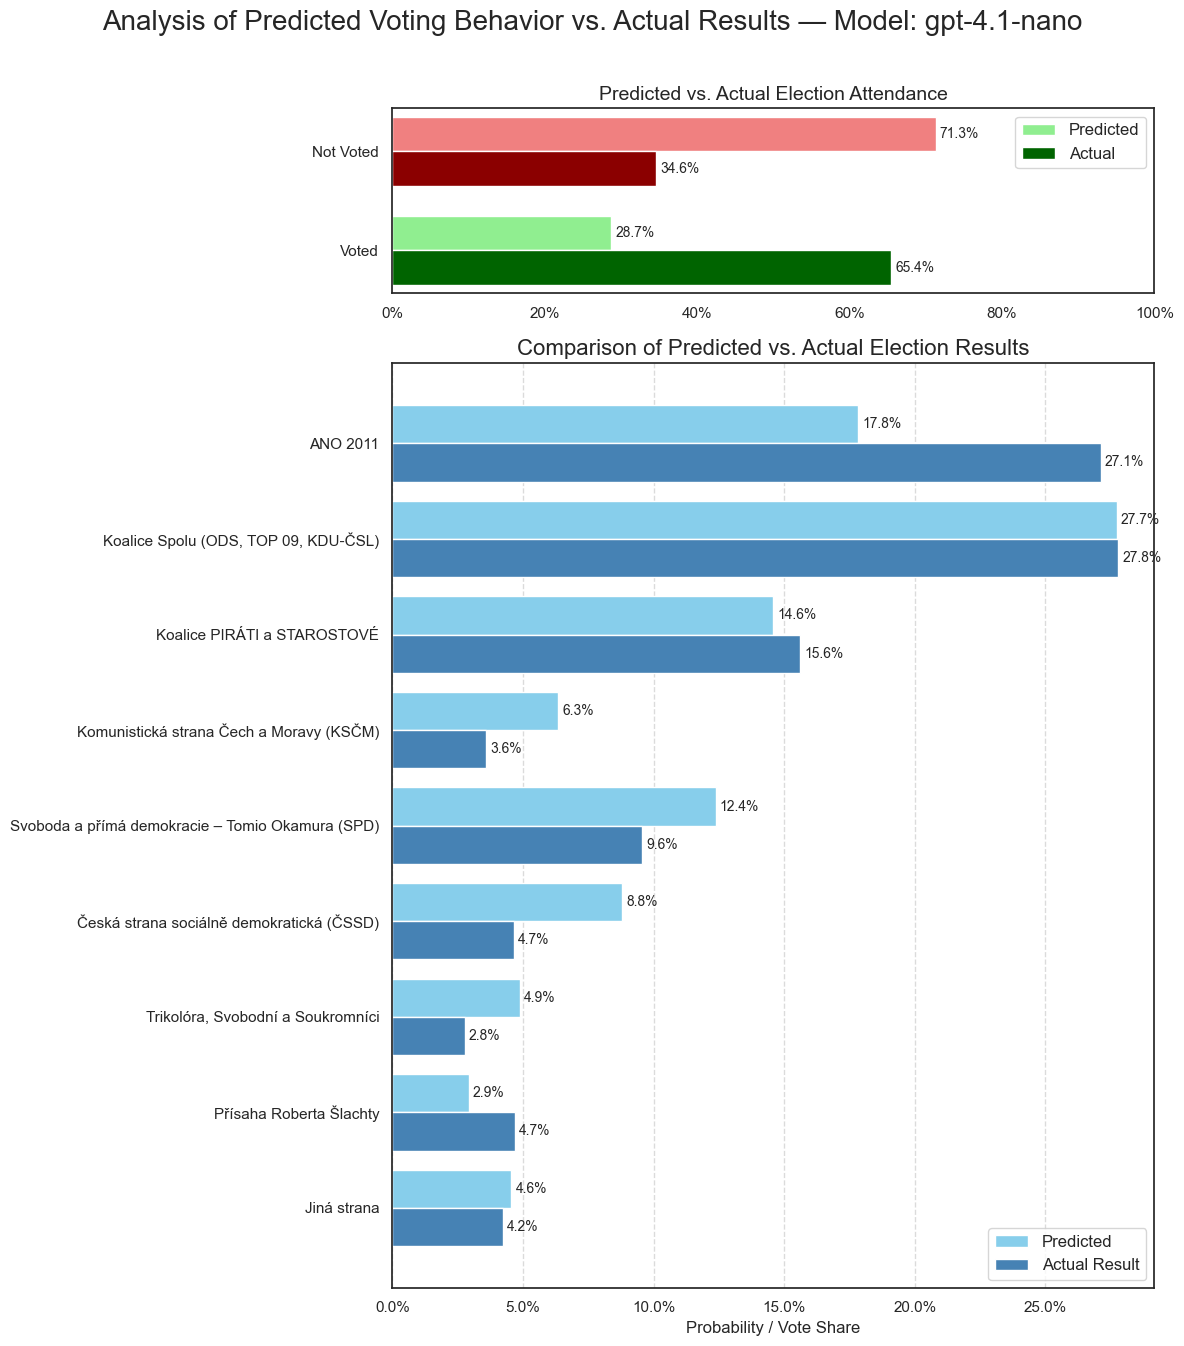

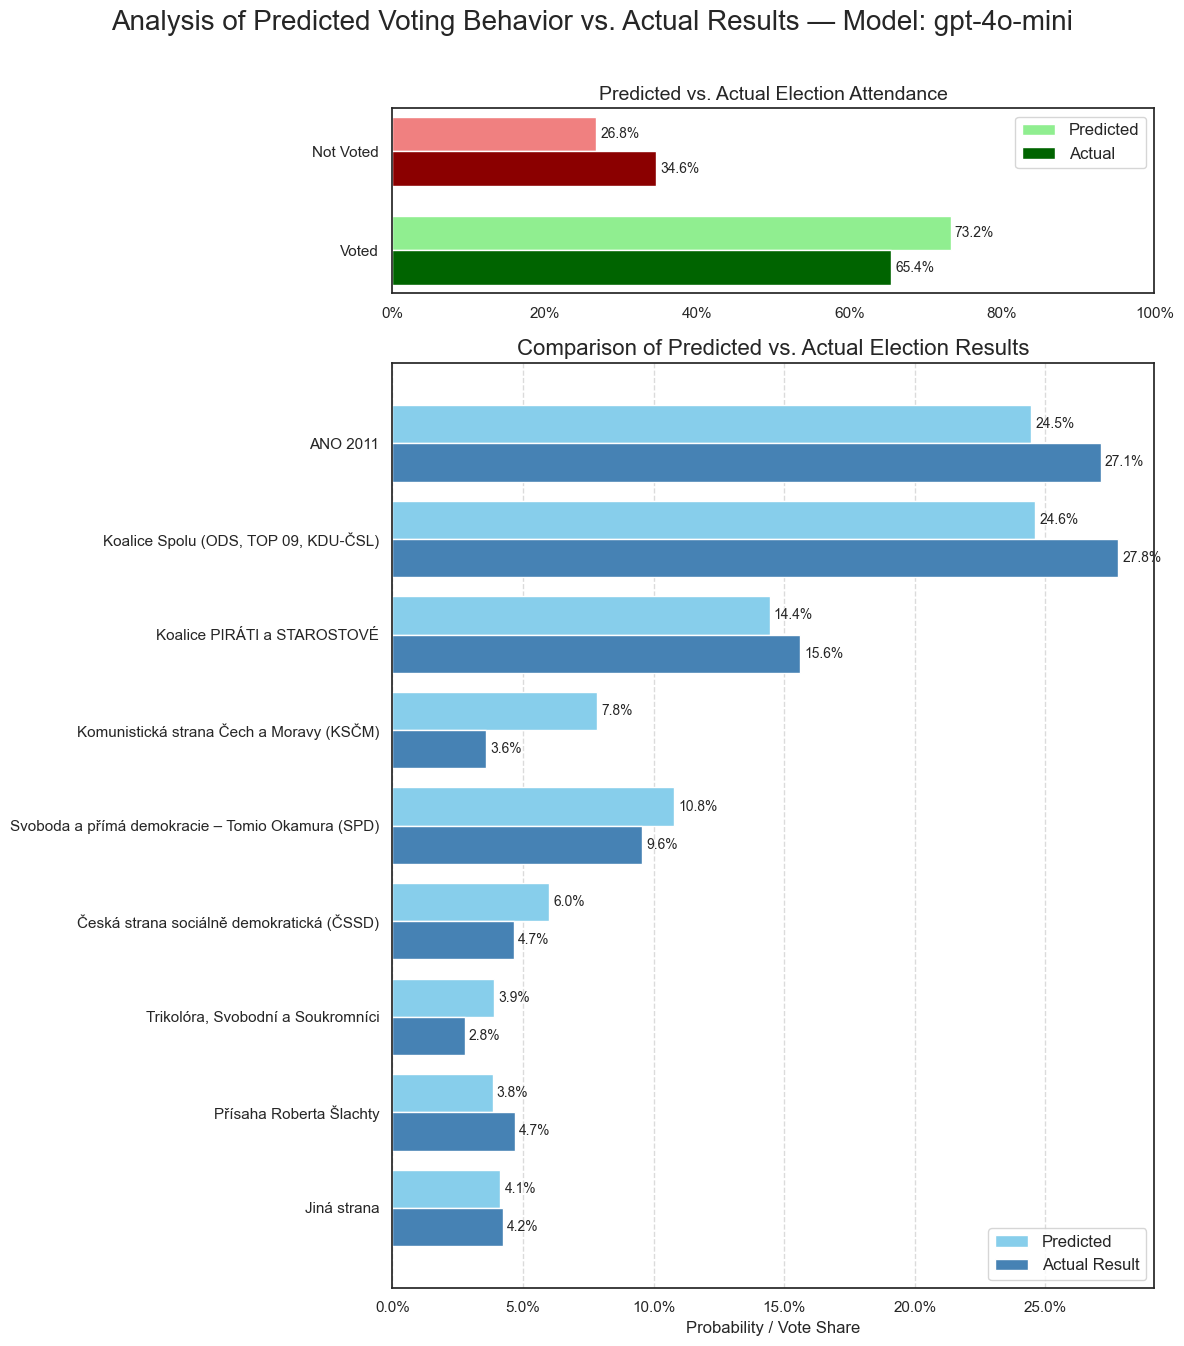

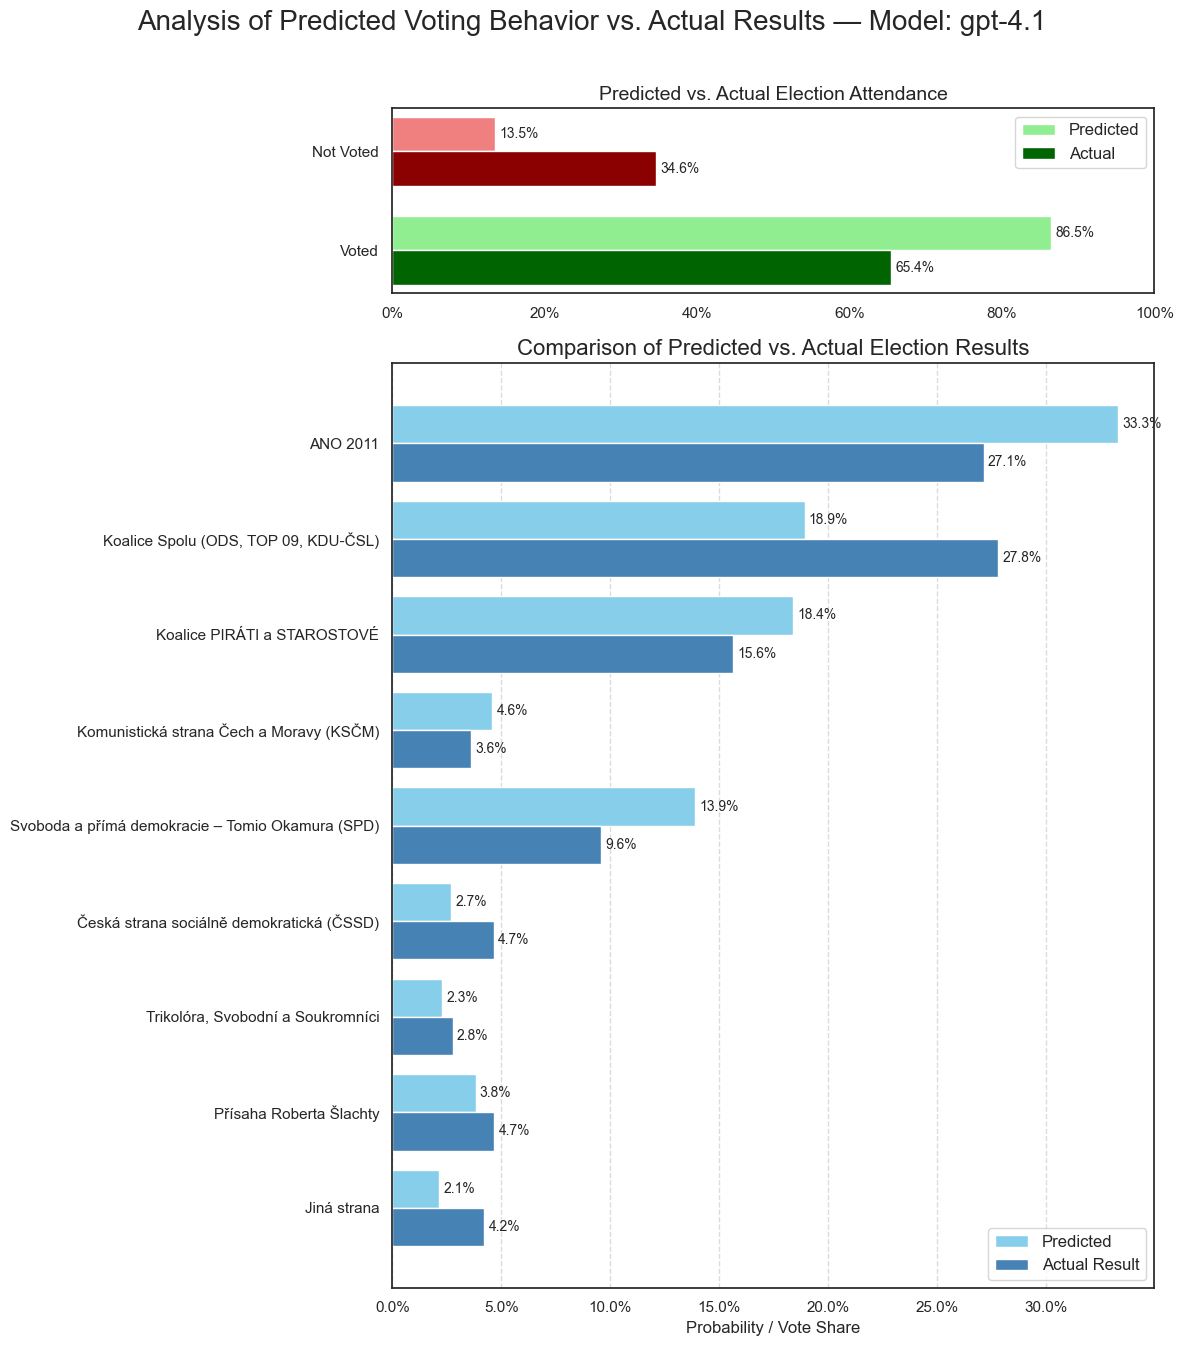

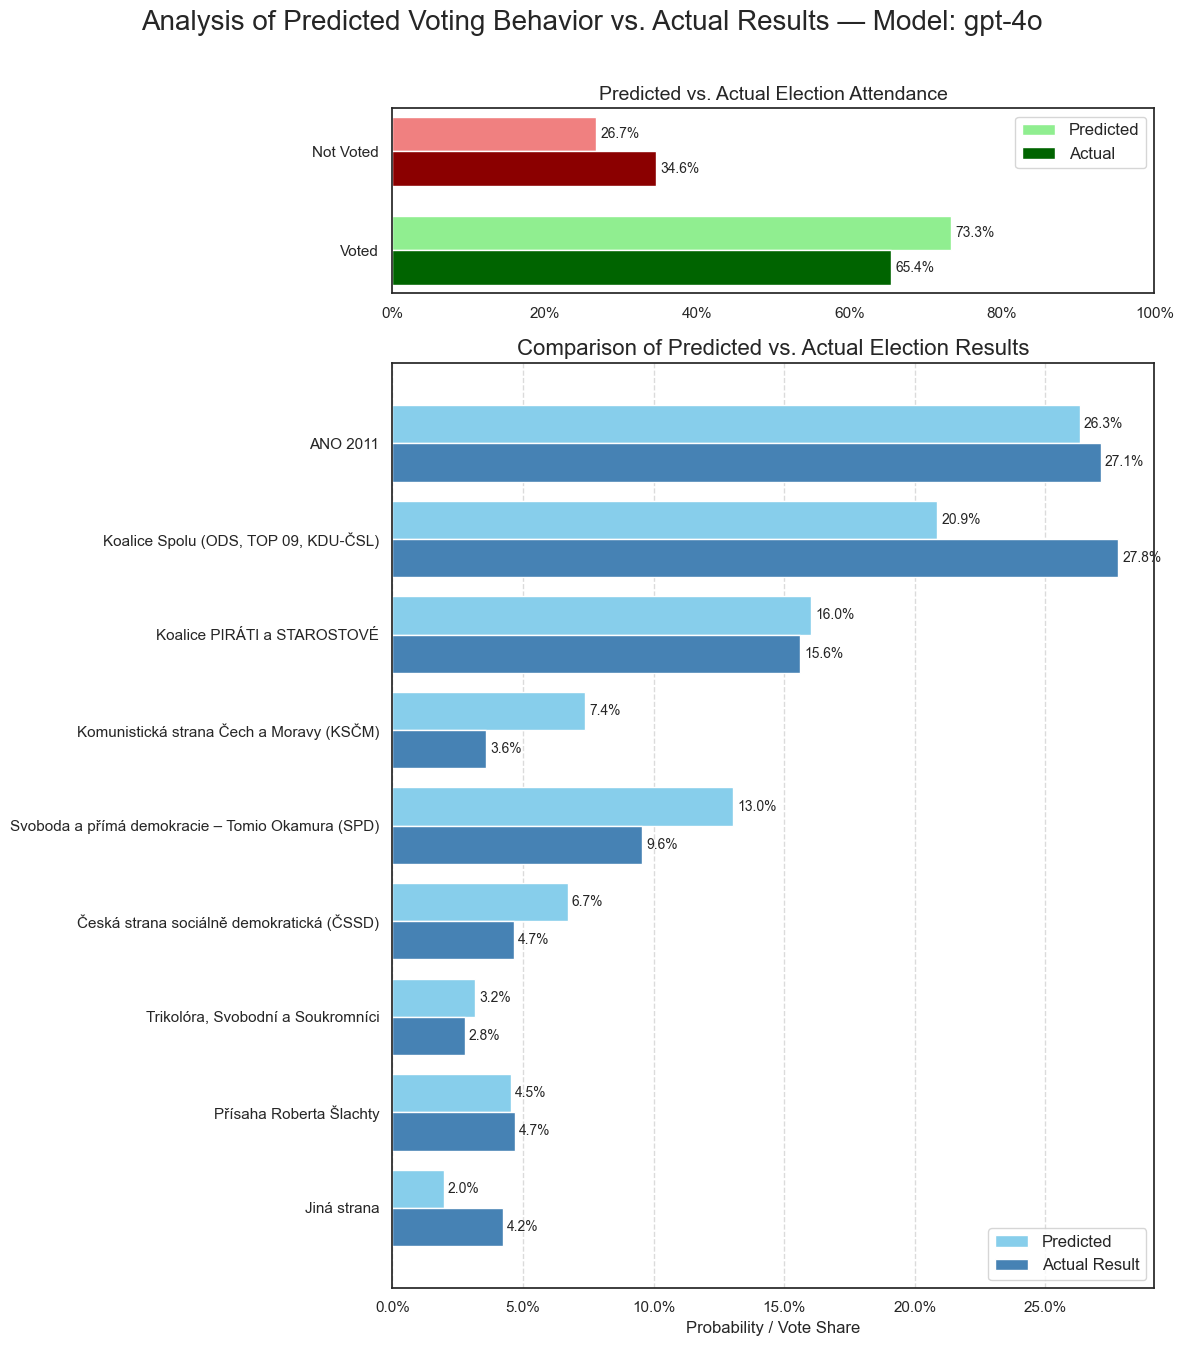

In [13]:
# Generate and save comparison graphs
for model_name, voting_results_model in zip(model_names, voting_results_list):
    if not voting_results_model:  # Skip if no results loaded
        continue
        
    predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(list(voting_results_model.values()), True)
    
    reload(Visualization_Utils)
    # Visualize the results
    fig = Visualization_Utils.visualize_comprehensive_results(
        predicted_parties,
        predicted_attendance,
        actual_parties,
        actual_attendance,
        model_name=model_name
    )
    # Save the plot as a PNG file
    if fig:
        fig.savefig(f"graphs/{model_name}.png")
        print(f"Saved graph for {model_name}")

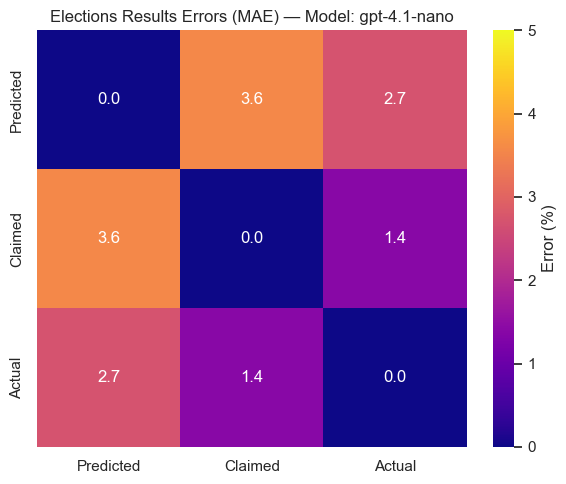

Saved graph for gpt-4.1-nano


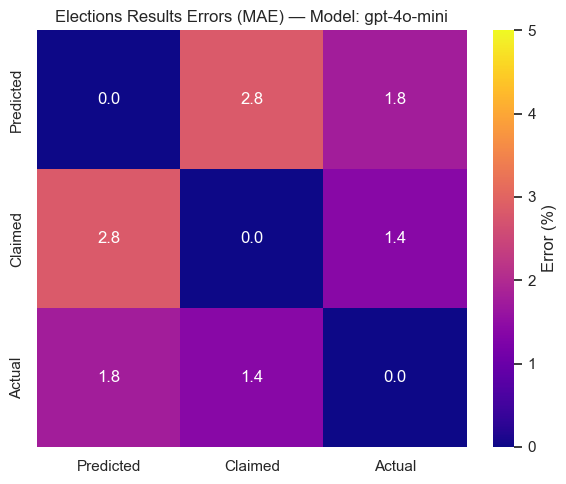

Saved graph for gpt-4o-mini


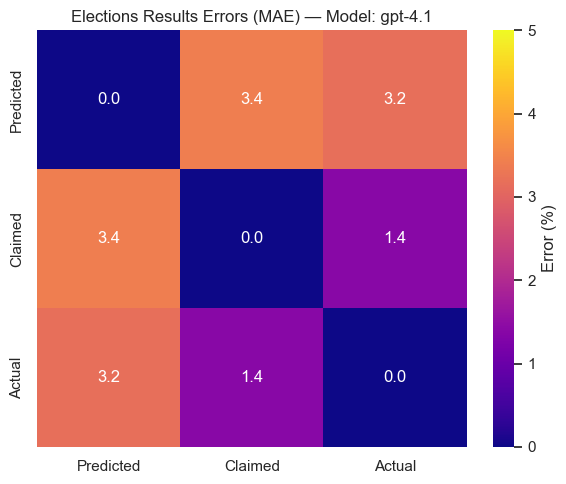

Saved graph for gpt-4.1


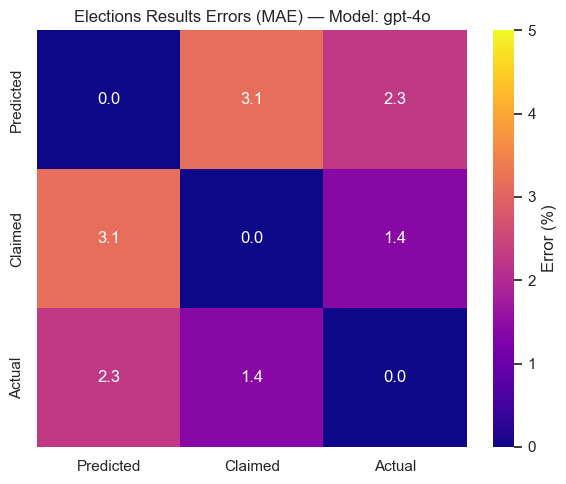

Saved graph for gpt-4o


In [15]:
# Generate error comparison for all models
# metric = 'RMSE'  # or 'MAE'
metric = 'MAE'

reload(Visualization_Utils)
for model_name, voting_results_model in zip(model_names, voting_results_list):
        
    predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(list(voting_results_model.values()), True)
    claimed_parties, claimed_attendance = SoD_Utils.get_actual_results(data, False)
    fig = Visualization_Utils.evaluate_polls(predicted_parties, claimed_parties, actual_parties, metric, "Elections Results", model_name)
    if fig:
        fig.savefig(f"graphs/{metric}_{model_name}.png")
        print(f"Saved graph for {model_name}")
    # Visualization_Utils.evaluate_polls(predicted_attendance, claimed_attendance, actual_attendance, metric, "Elections Attendance", model_name, 15)

## Region Analysis

In [ ]:
# TODO:
# rerun uncertain, a rozpad po krajoch

In [20]:
model = "gpt-4o"
temperature = 0

region_indices = df.groupby('KRAJ', observed=True).groups

# Load results
voting_results = Save_Utils.load_results_from_json(
    f"results/voting_results_n=3880_t={temperature}_{model}.json",
    VotingResult.VotingResult
)

Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o.json


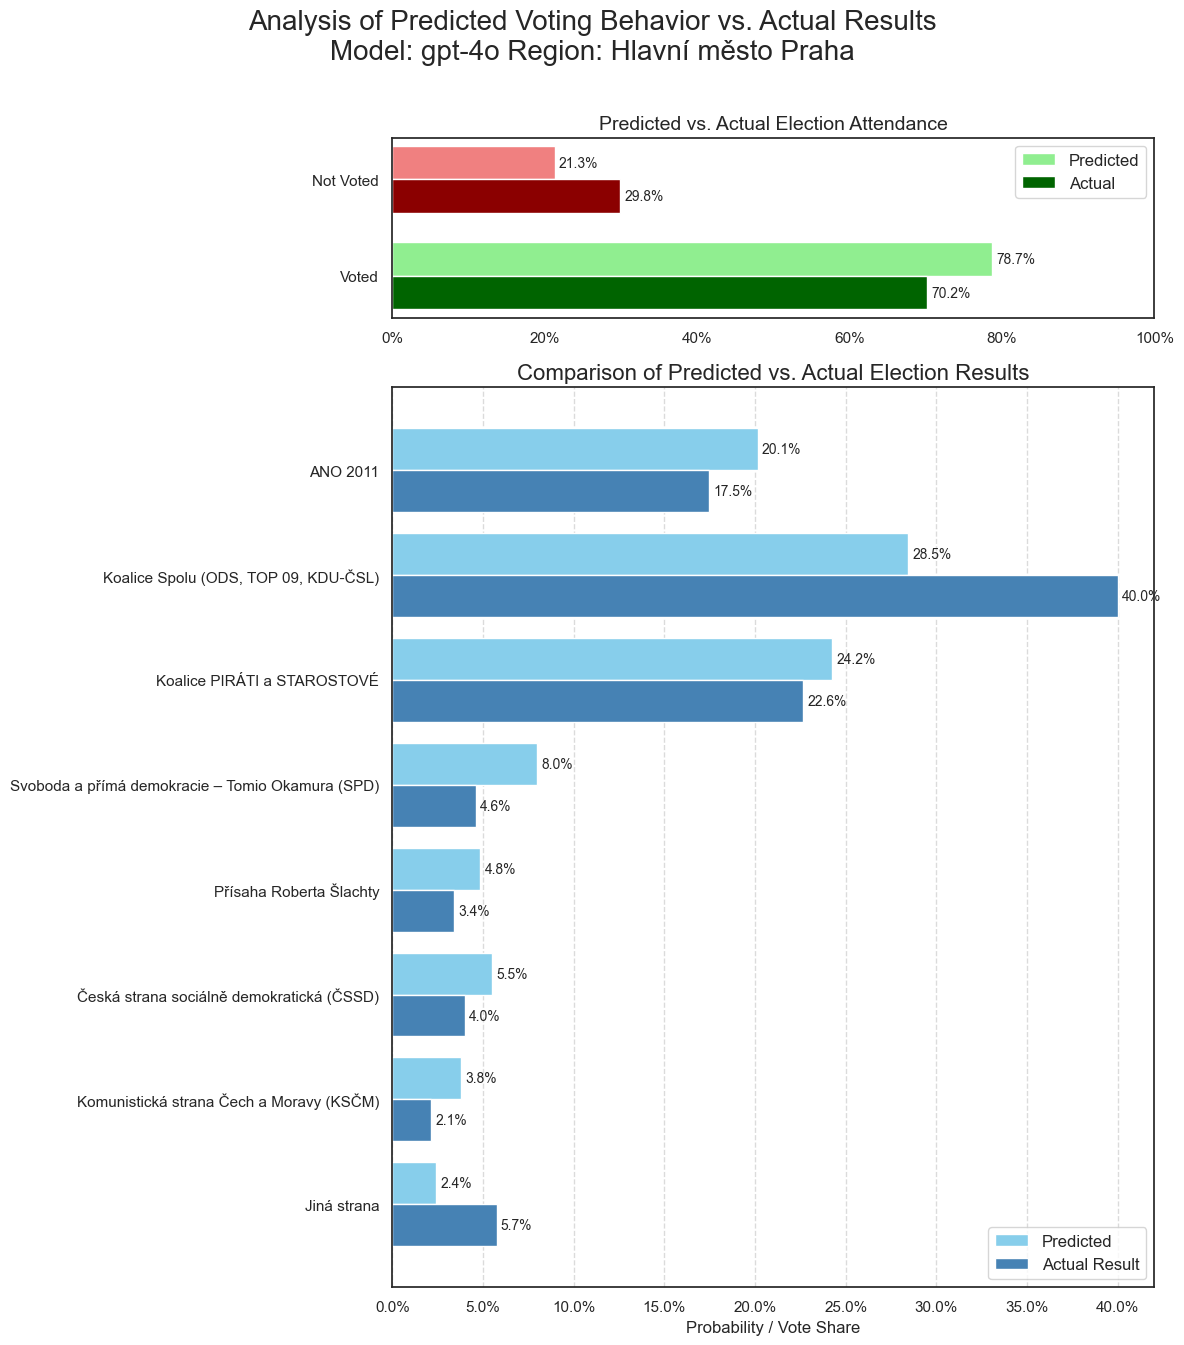

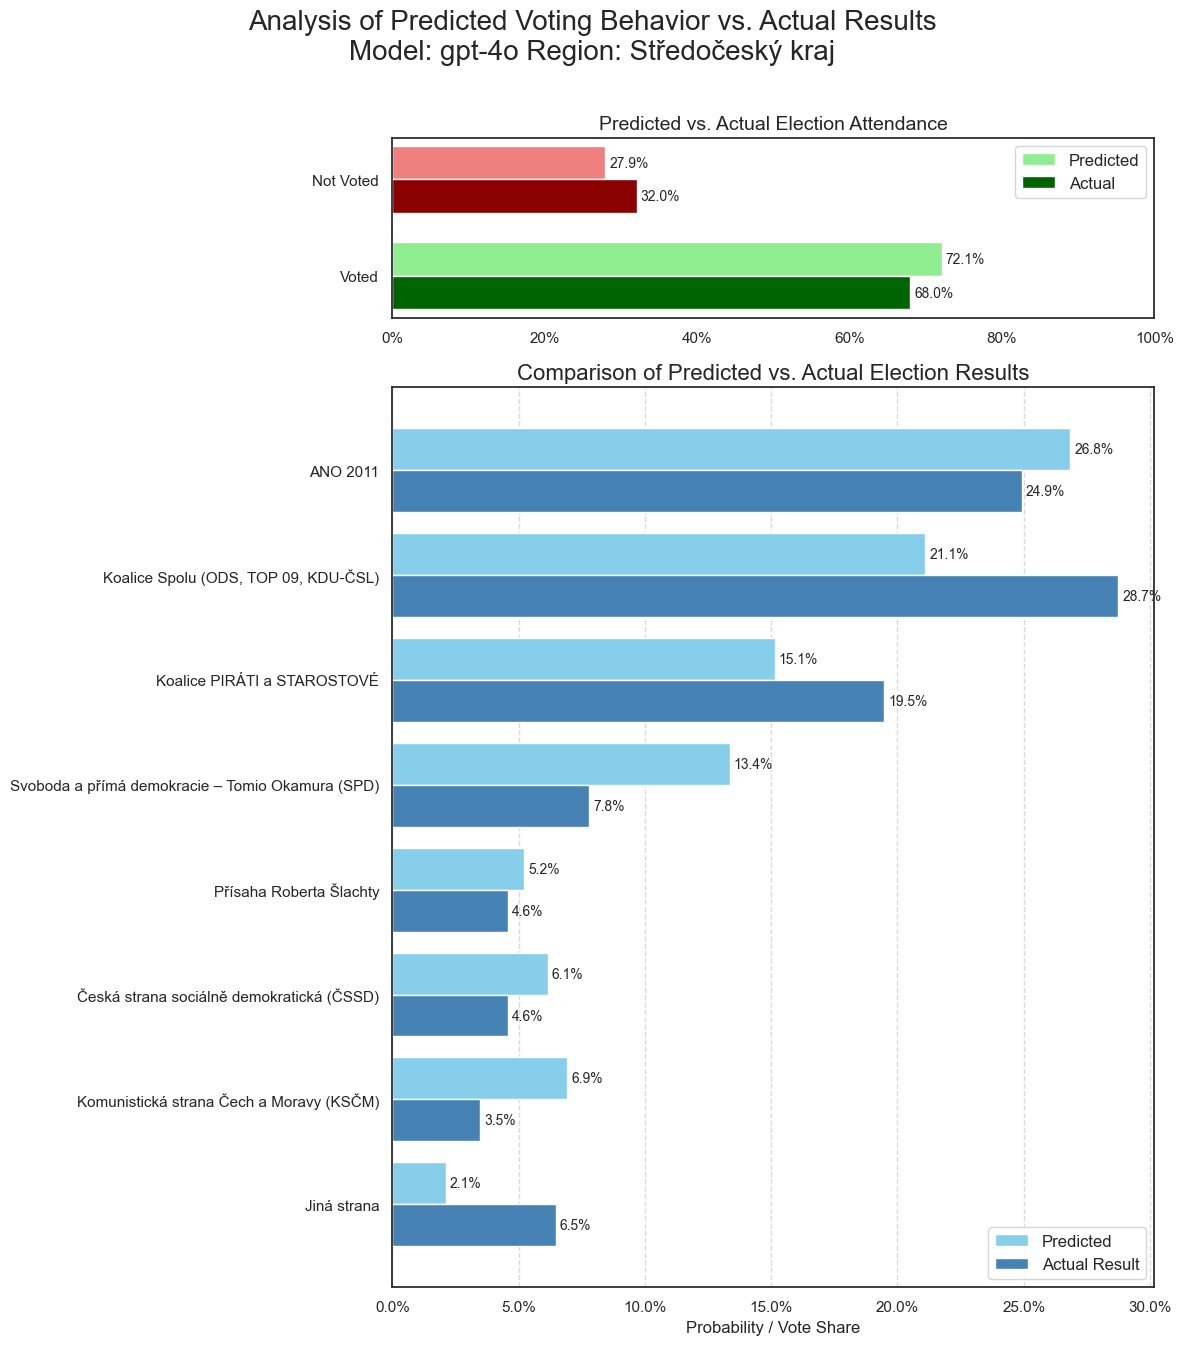

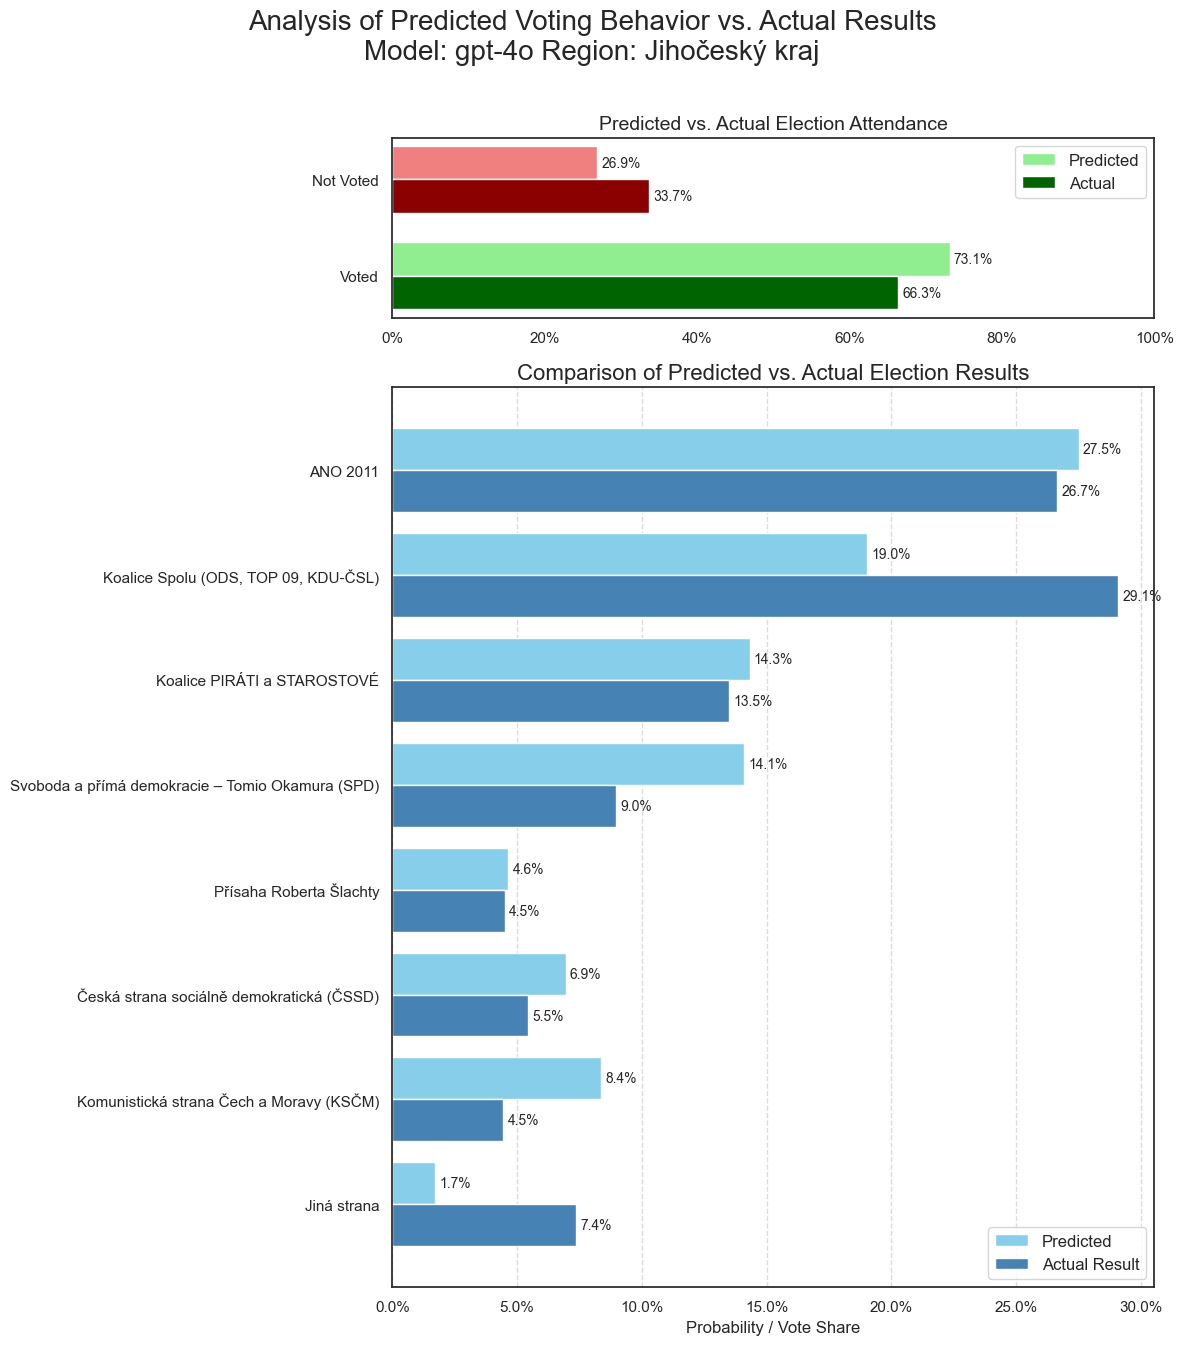

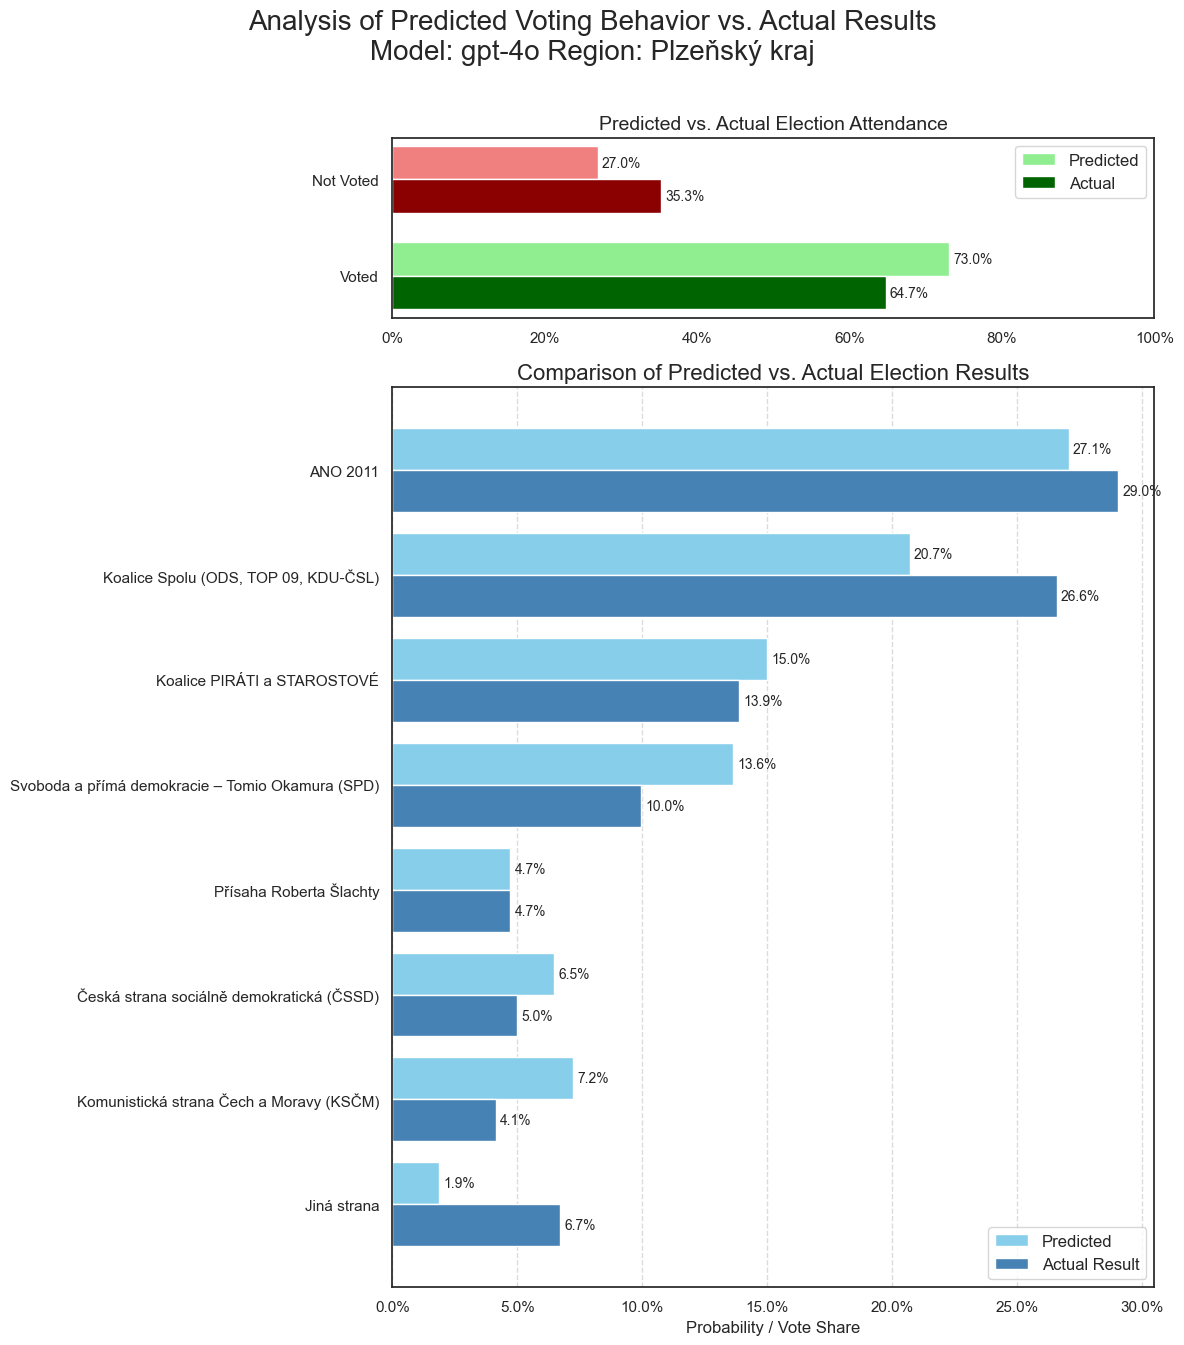

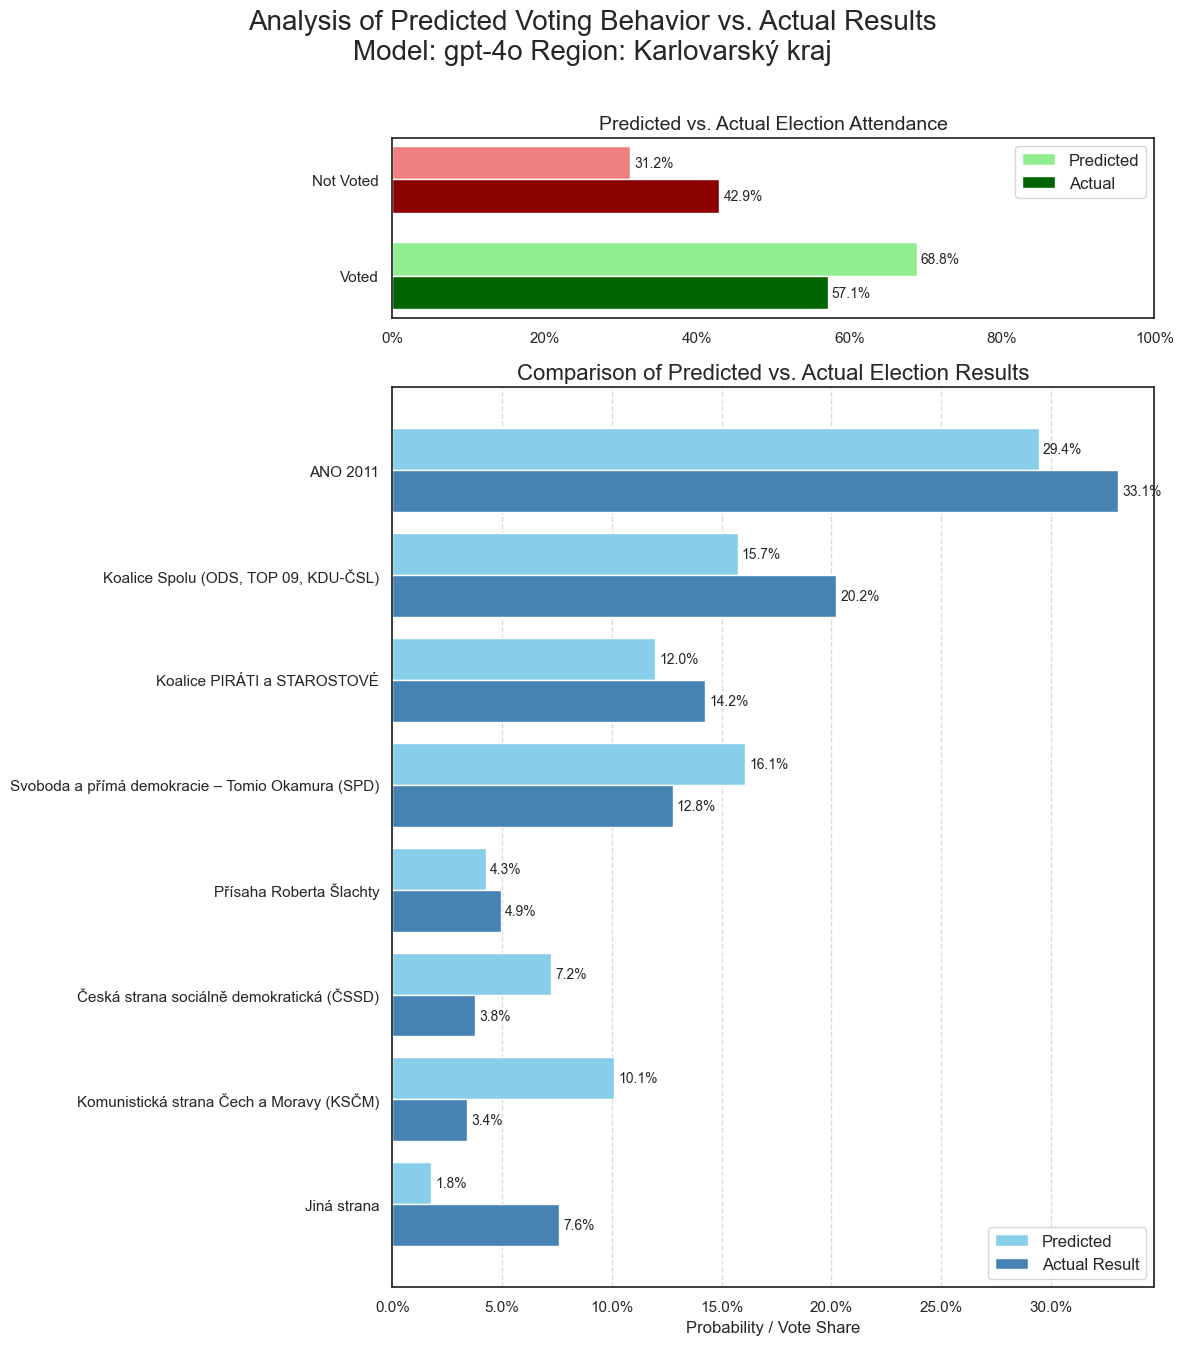

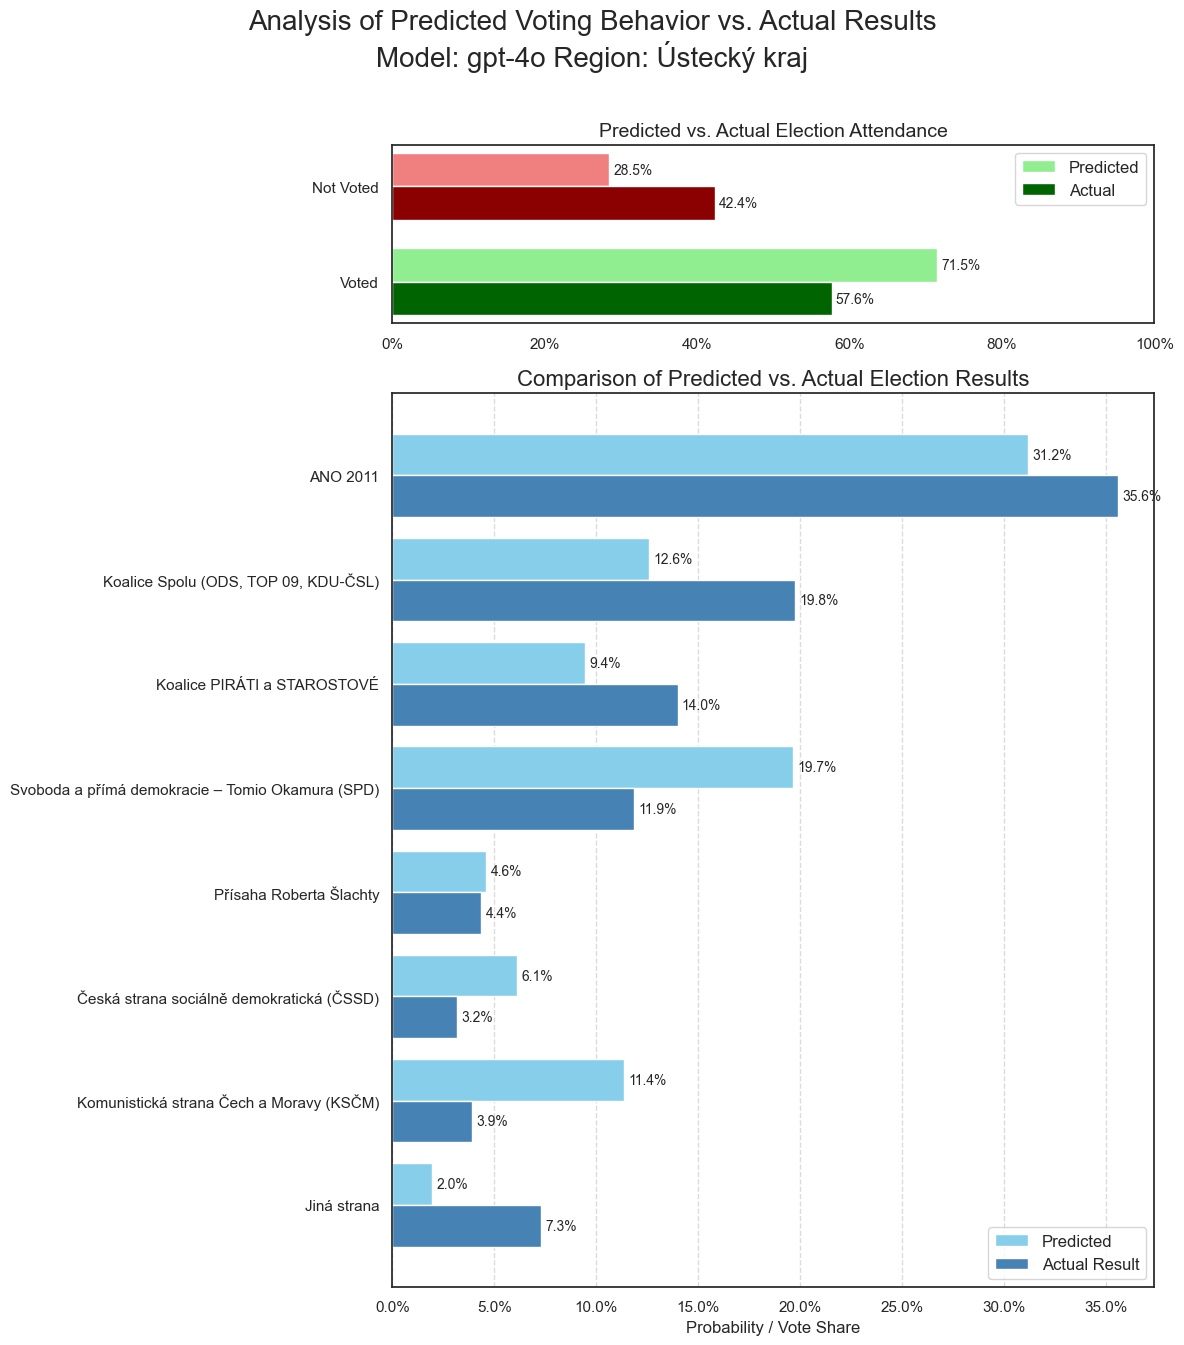

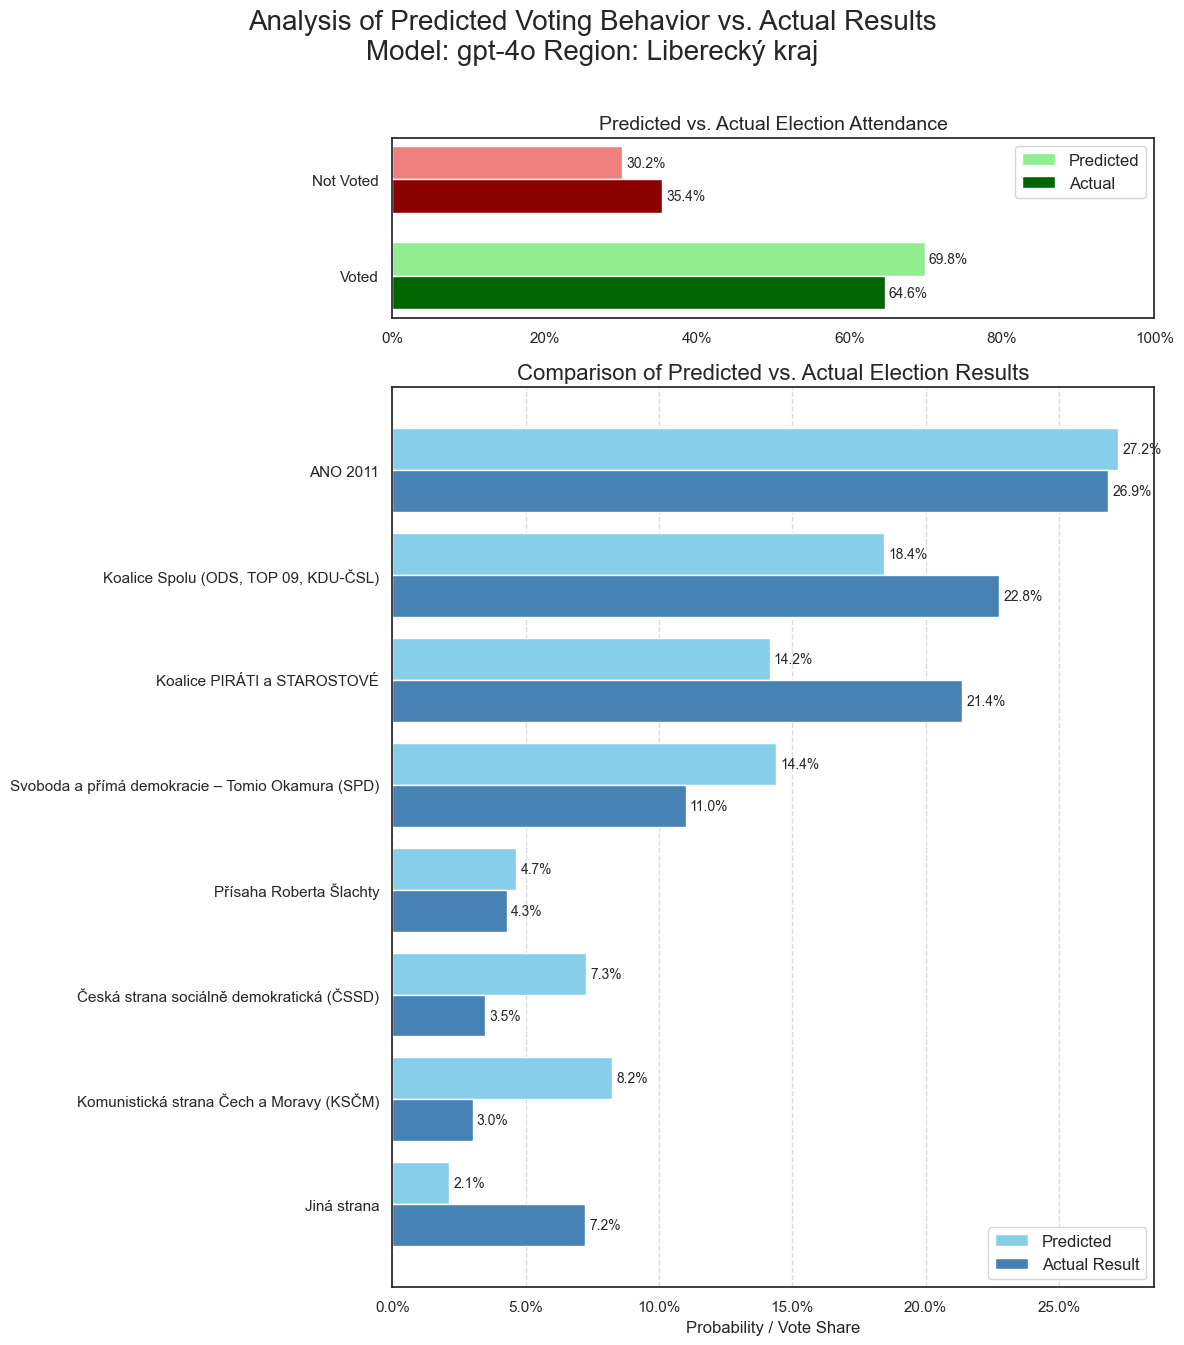

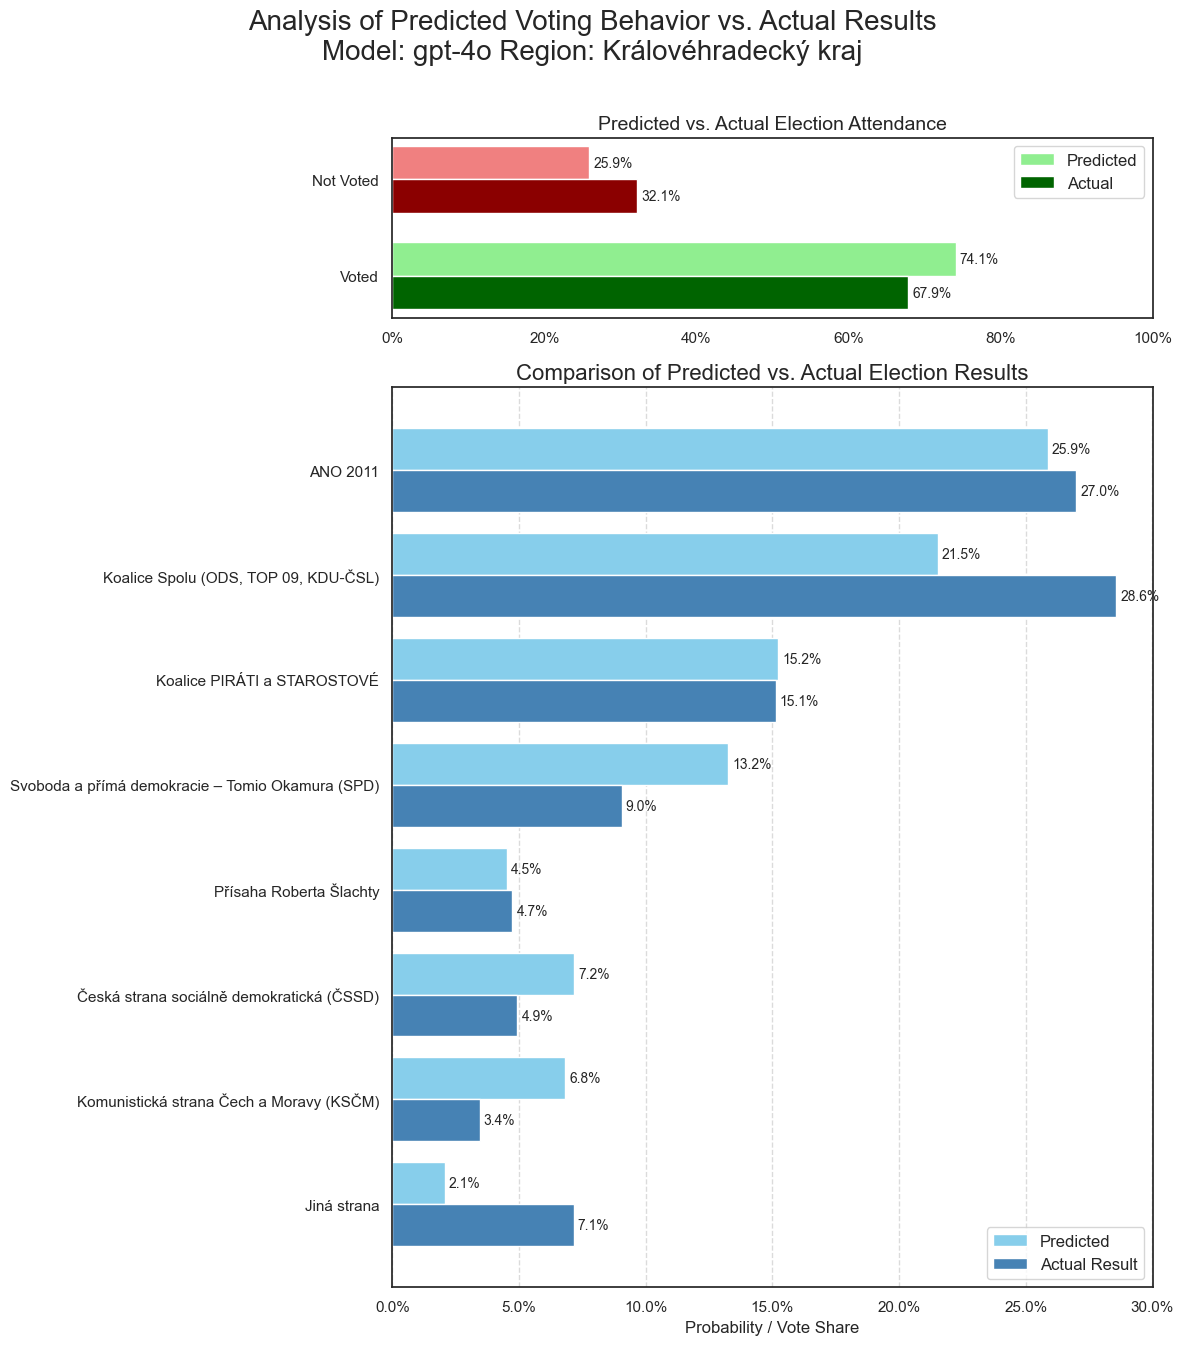

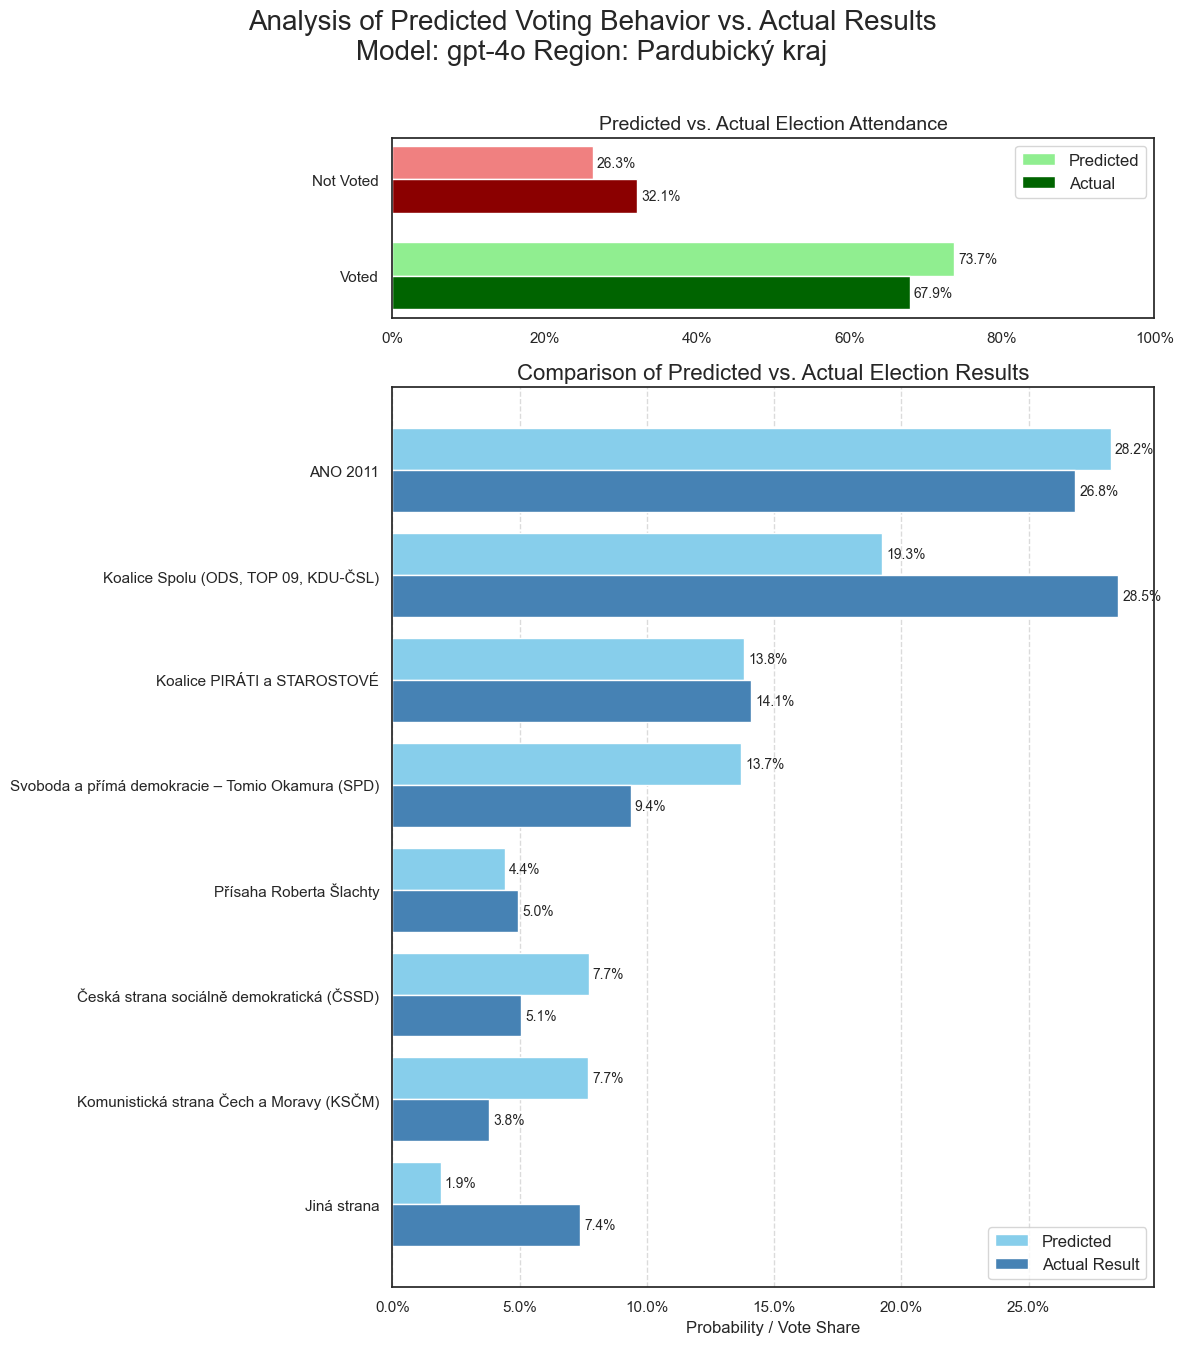

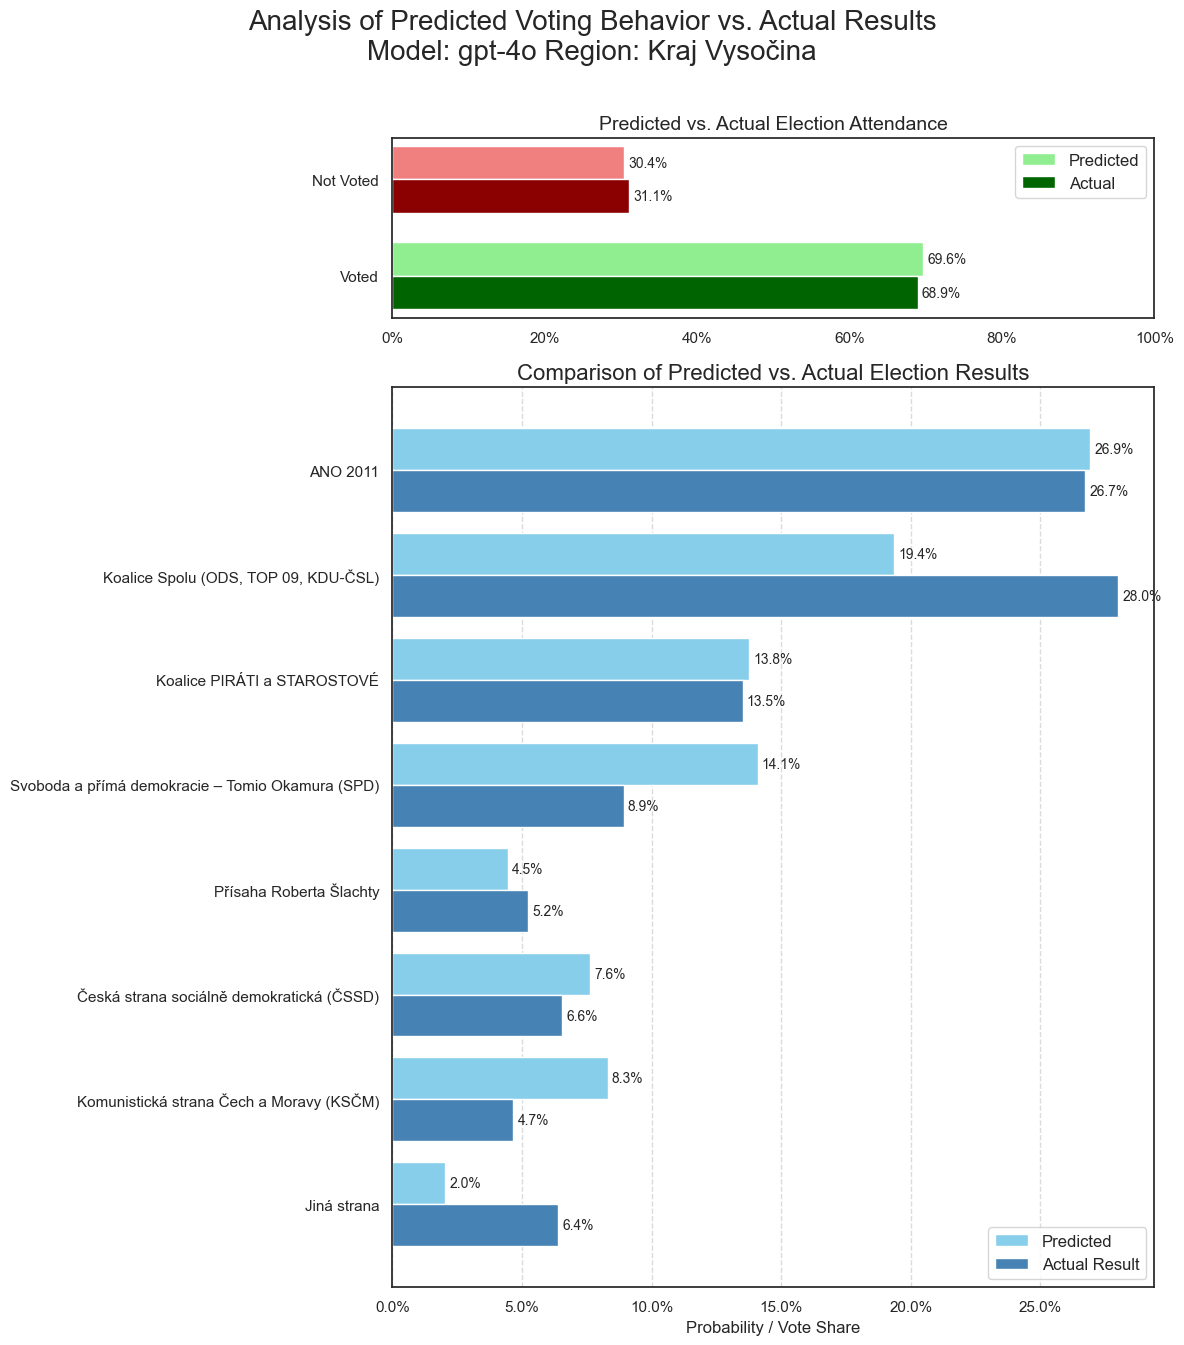

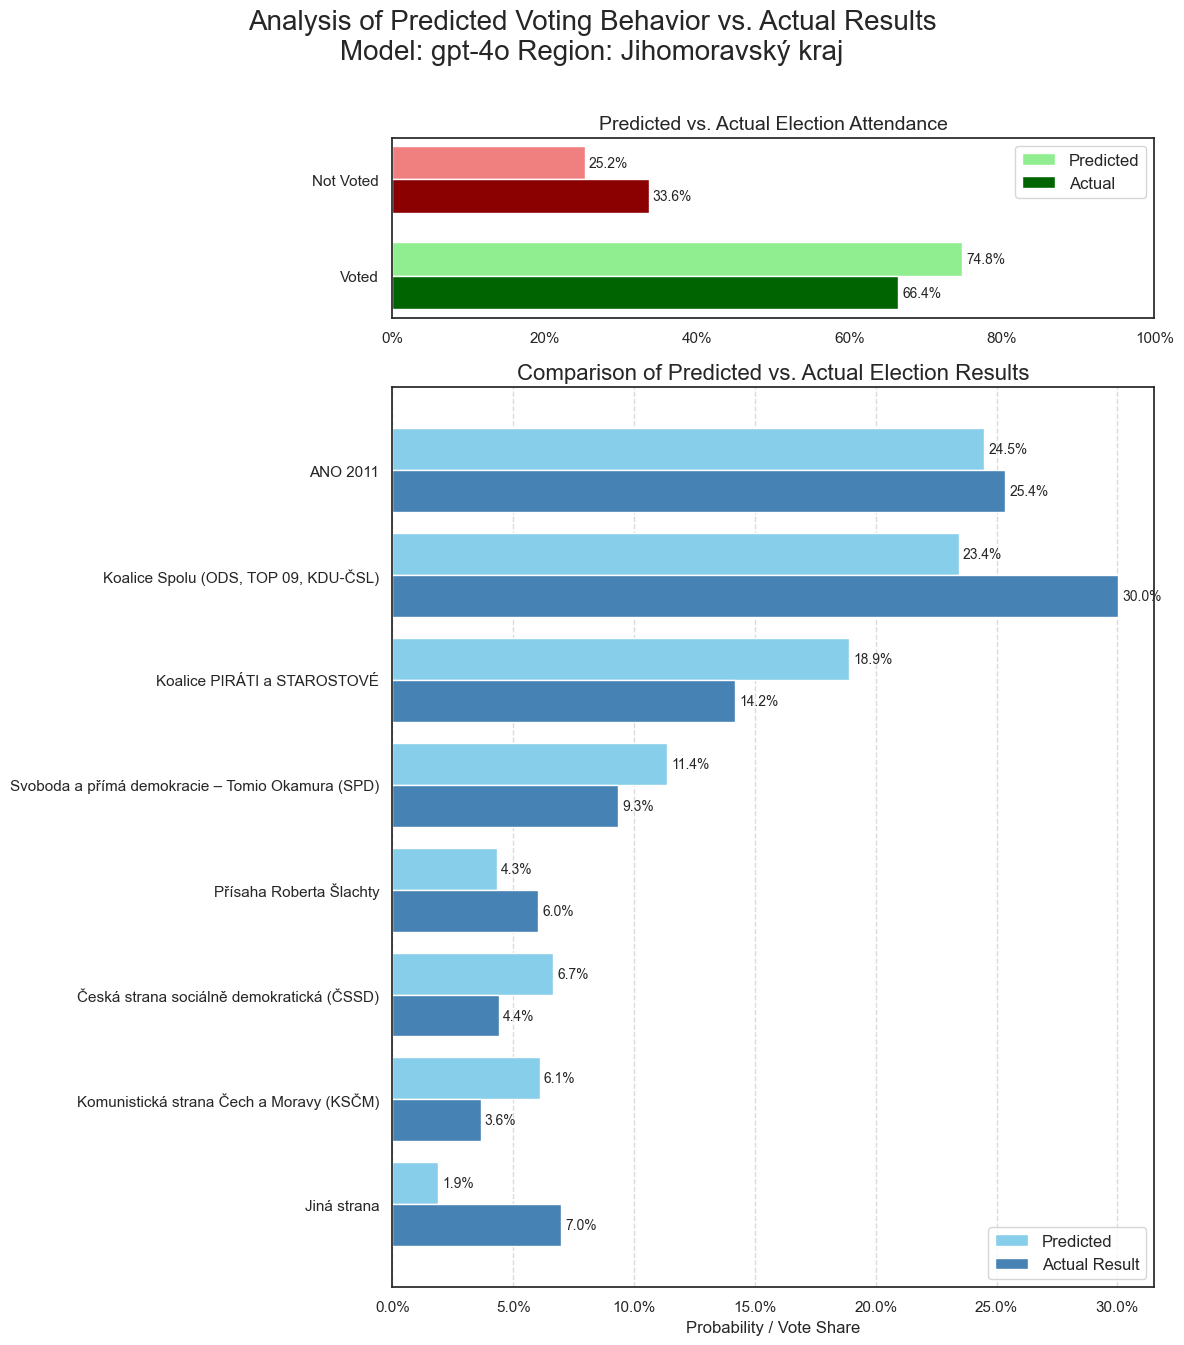

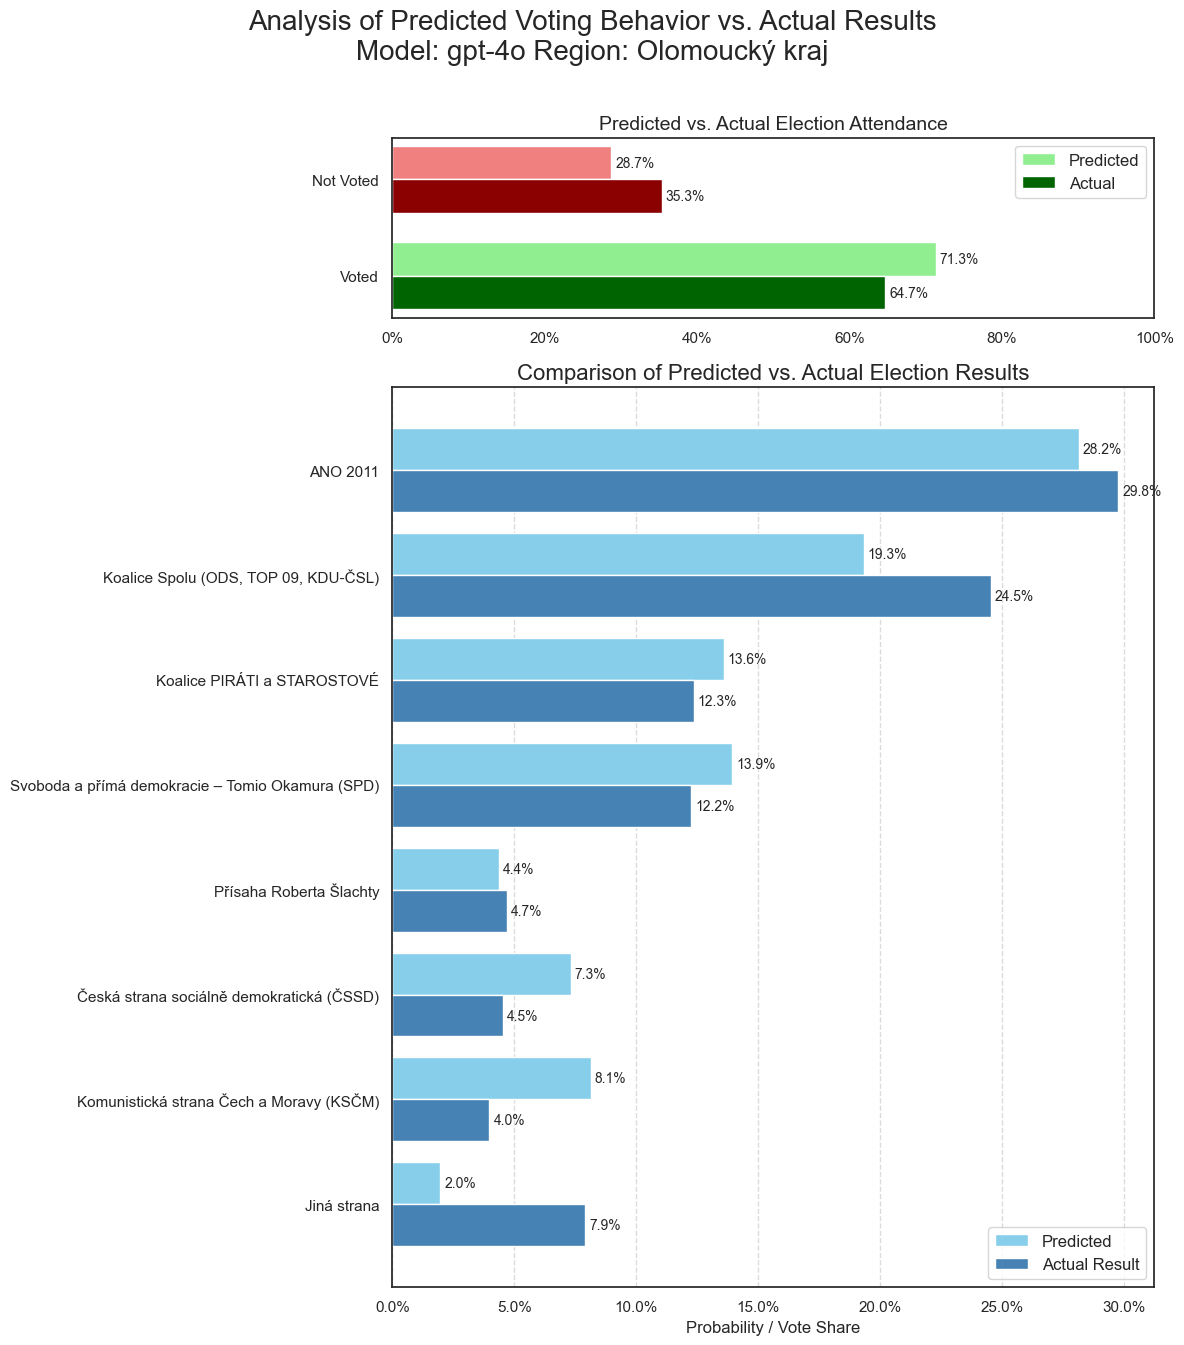

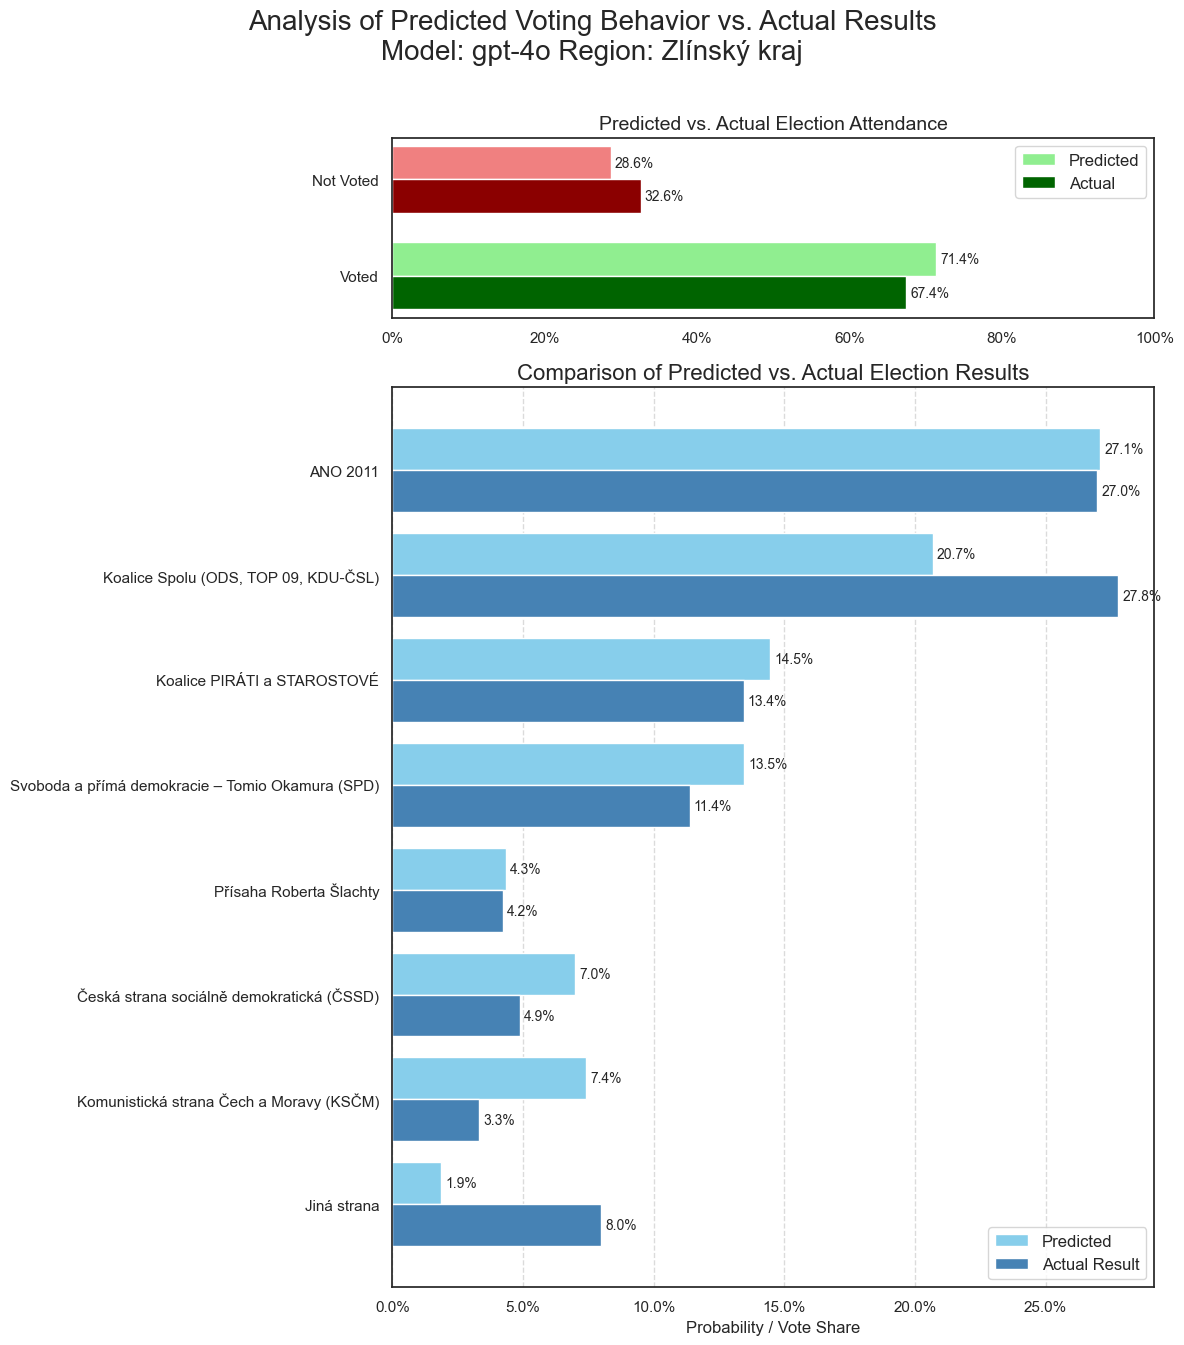

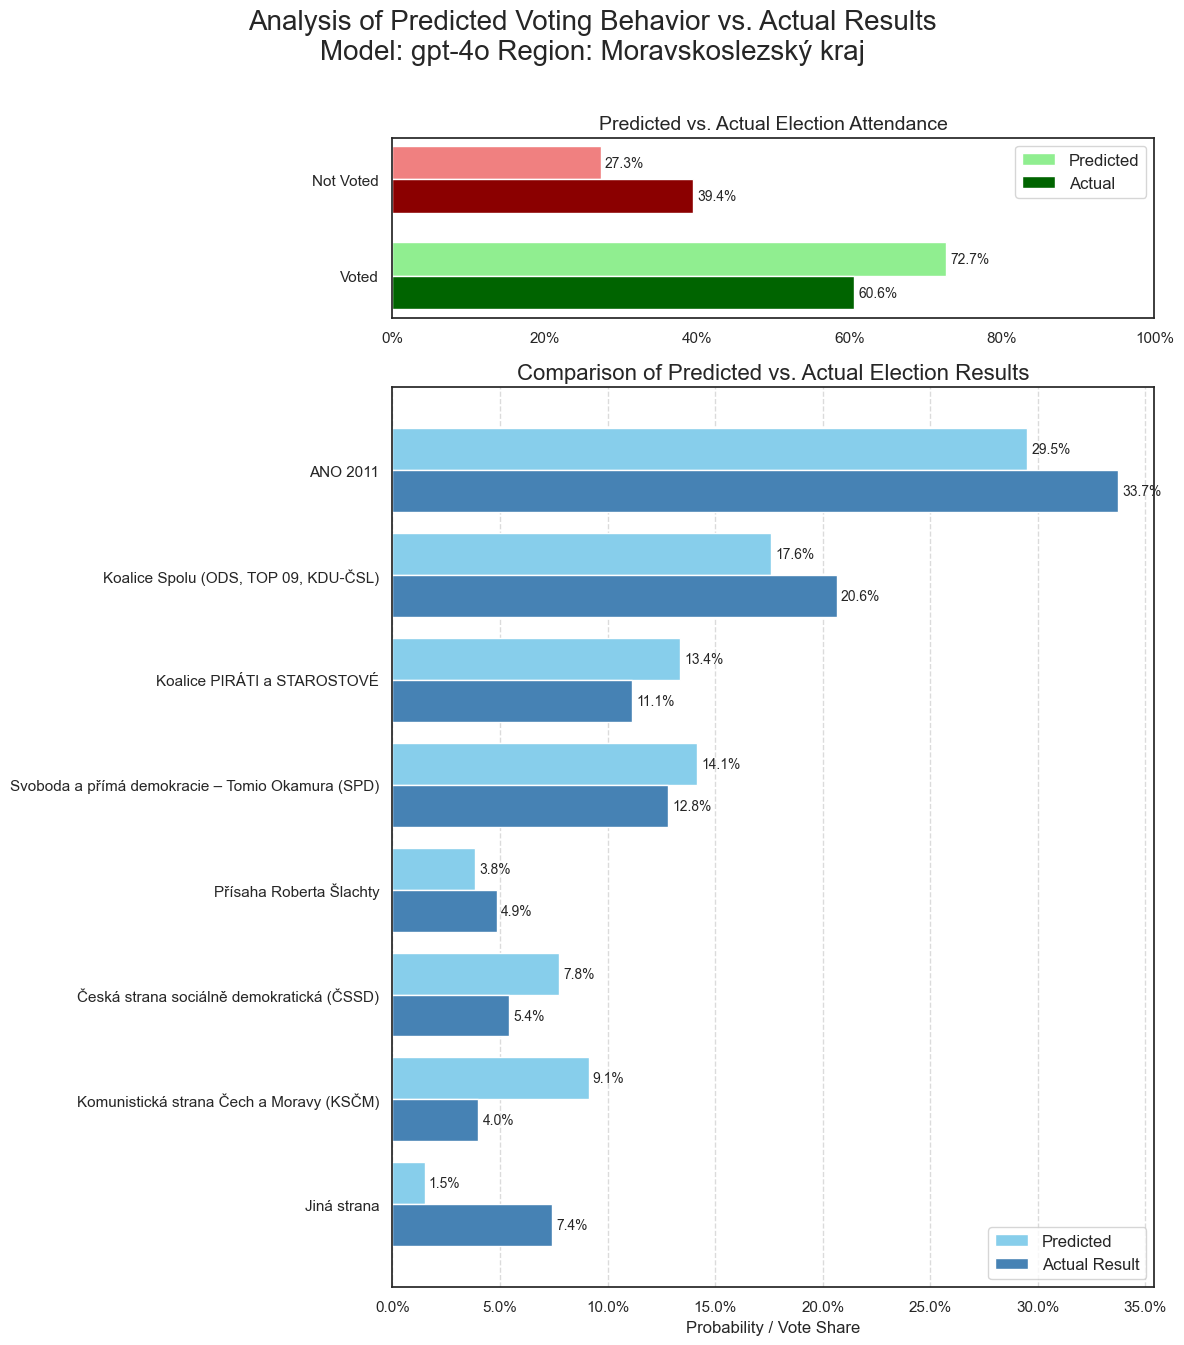

In [21]:
# Generate aggregated results and visualizations
reload(Visualization_Utils)
for region, (actual_attendance,actual_parties) in Data.ELECTION_REGION_DATA.items():
    predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(list([voting_results[index] for index in region_indices[region]]), True)
    # Visualize the results
    fig = Visualization_Utils.visualize_comprehensive_results(
        predicted_parties,
        predicted_attendance,
        actual_parties,
        actual_attendance,
        model_name=f"{model} Region: {region}"
    )

Successfully loaded 3880 results (with IDs) from results/voting_results_n=3880_t=0_gpt-4o.json


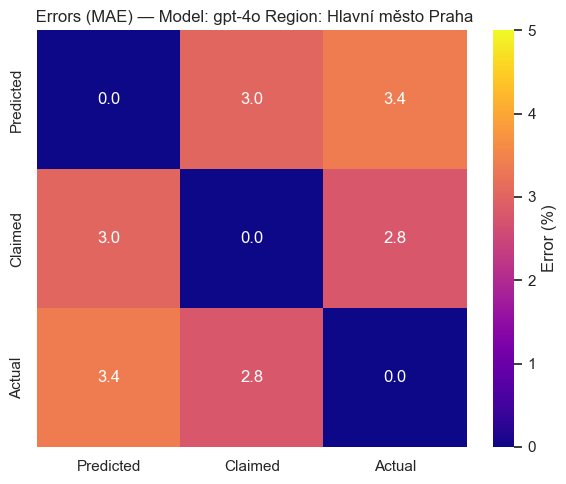

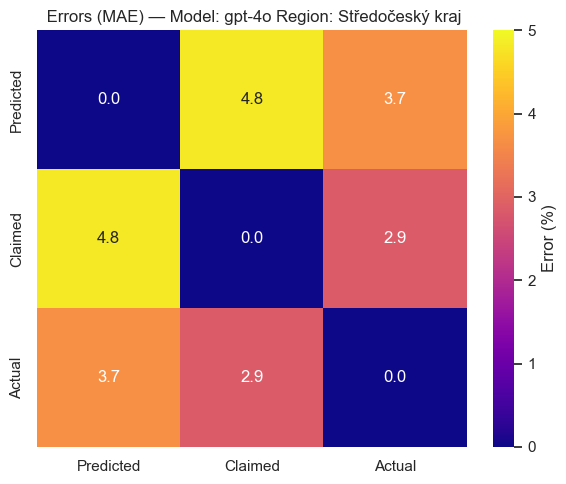

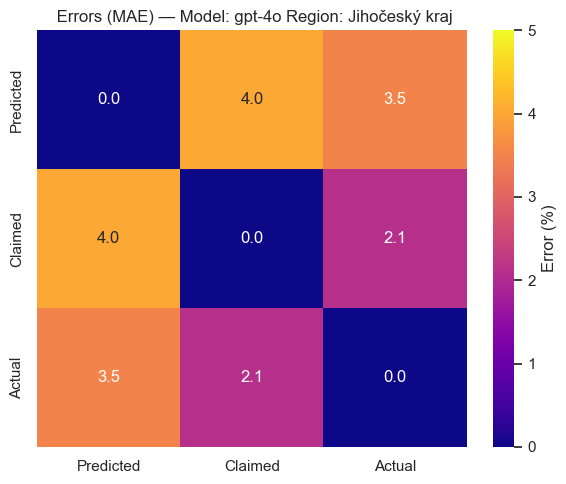

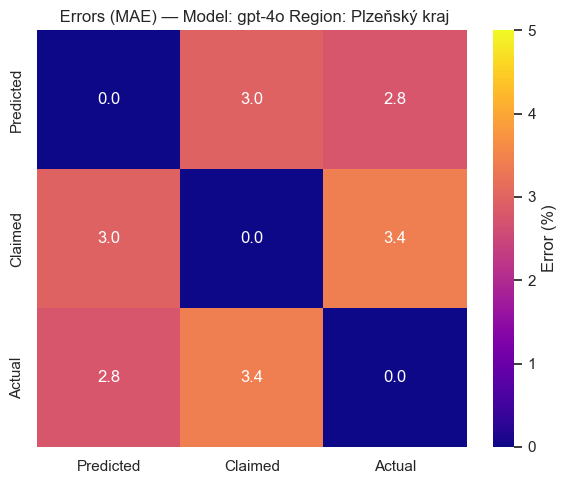

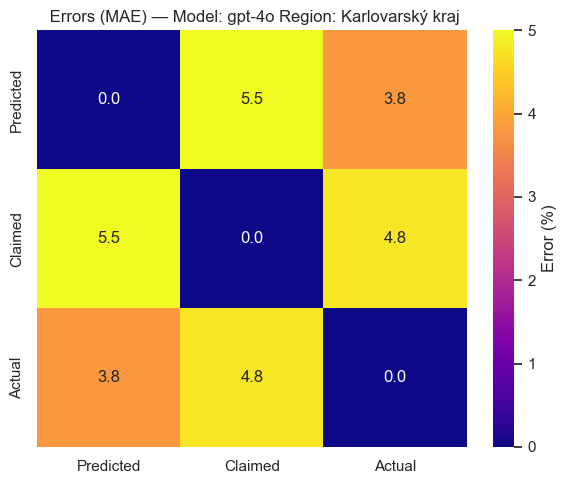

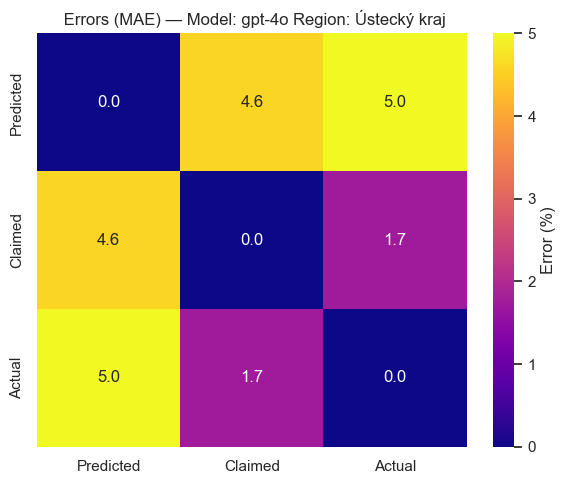

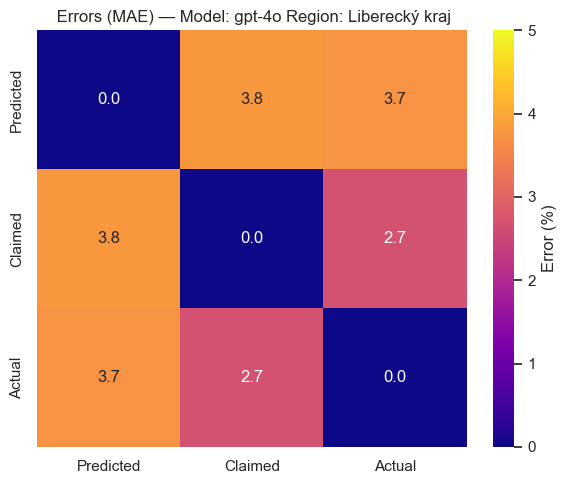

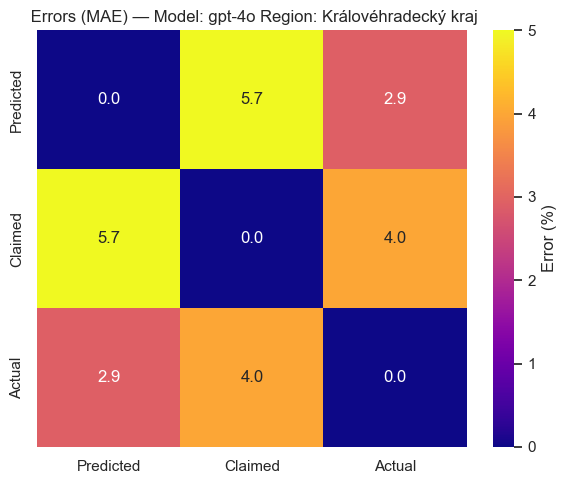

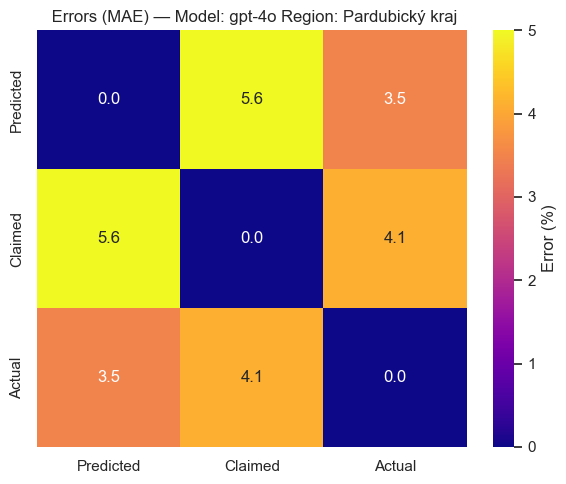

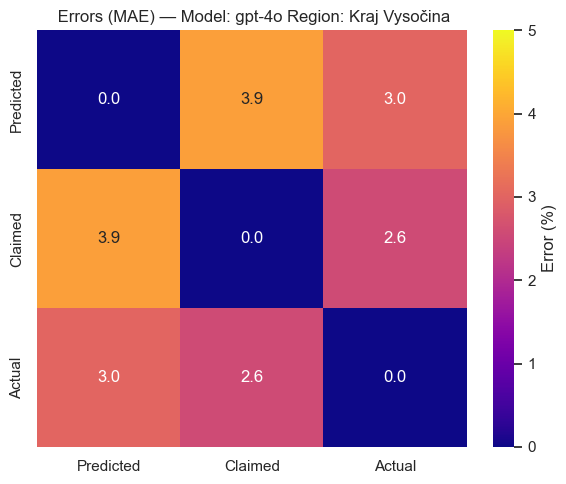

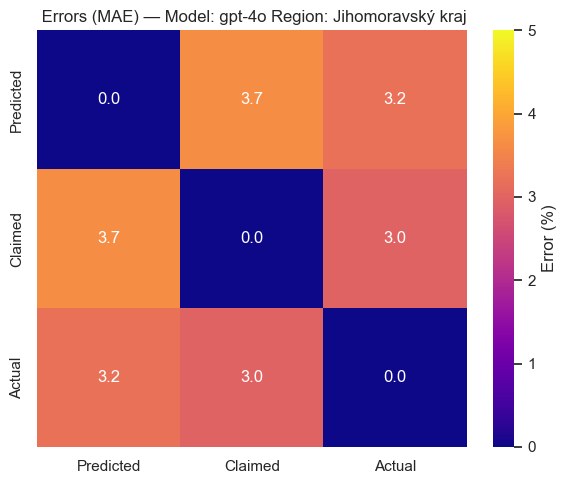

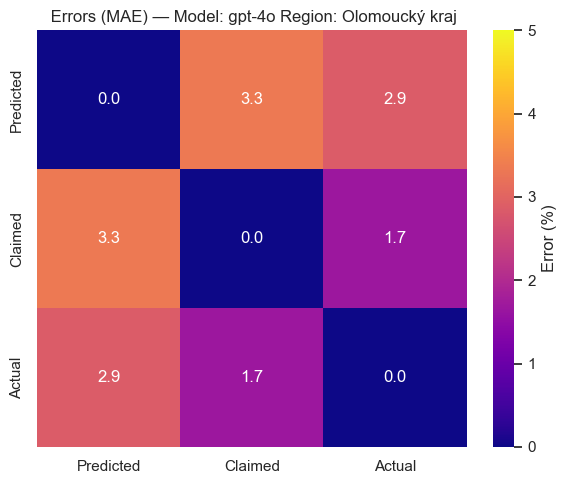

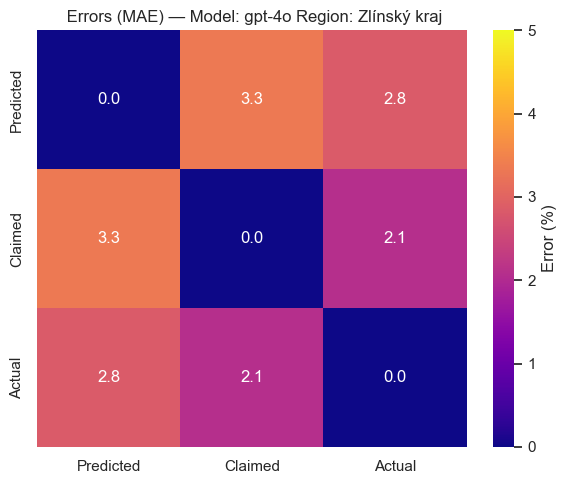

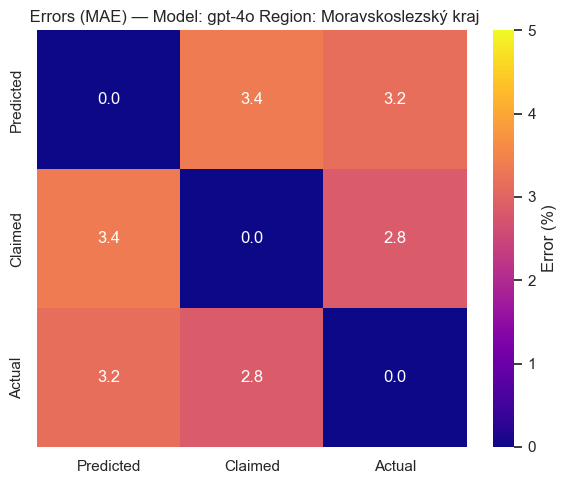

In [19]:
# Generate aggregated results and visualizations
reload(Visualization_Utils)
for region, (actual_attendance,actual_parties) in Data.ELECTION_REGION_DATA.items():
    predicted_parties, predicted_attendance = Visualization_Utils.aggregate_results(list([voting_results[index] for index in region_indices[region]]), True)
    claimed_parties, claimed_attendance = SoD_Utils.get_actual_results(data.iloc[region_indices[region]], False)
    # Visualize the results
    fig = Visualization_Utils.evaluate_polls(
        predicted_parties,
        claimed_parties,
        actual_parties,
        model_name=f"{model} Region: {region}"
    )